# ESM-GCN
---
## Extracting Wildtype Binding and Expression
To have our comparison to the wildtype values, we need to extract the predictions. We'll find the average value for each binding and expression and plot them on the scatter plot. From this, we can get the R^2 values.

In [16]:
import os
import sys
import tqdm
import time
import torch
import random
import datetime
import pandas as pd
import numpy as np
from typing import Union
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, EsmModel

def load_model(saved_model_pth, device):
    saved_state = torch.load(saved_model_pth, map_location=device)

    model_state = saved_state['model_state_dict']
    optimizer_state = saved_state['optimizer_state_dict']

    epoch = saved_state['epoch']
    loss = saved_state['loss']

    print(f"Loaded in model from {saved_model_pth}, saved at epoch {epoch}, rmse loss {loss}")
    return model_state, optimizer_state, epoch, loss

class DMSDataset(Dataset):
    """ Binding or Expression DMS Dataset, single target. """
    
    def __init__(self, csv_file:str, result_tag:str):
        """
        Load from csv file into pandas:
        - sequence label ('labels'), 
        - 'sequence',
        - binding or expression target,
        """
        try:
            self.full_df = pd.read_csv(csv_file, sep=',', header=0)
            self.target = 'ACE2-binding_affinity' if 'binding' in result_tag else 'RBD_expression'
        except (FileNotFoundError, pd.errors.ParserError, Exception) as e:
            print(f"Error reading in .csv file: {csv_file}\n{e}", file=sys.stderr)
            sys.exit(1)

    def __len__(self) -> int:
        return len(self.full_df)

    def __getitem__(self, idx):
        # label, seq, target
        return self.full_df['label'][idx], self.full_df['sequence'][idx], self.full_df[self.target][idx]
    
class DMSDataset_BE(Dataset):
    """ Binding and Expression DMS Dataset, multi target. """
    
    def __init__(self, csv_file:str):
        """
        Load from csv file into pandas:
        - sequence label ('labels'), 
        - 'sequence',
        - binding target,
        - expression target
        """
        try:
            self.full_df = pd.read_csv(csv_file, sep=',', header=0)
        except (FileNotFoundError, pd.errors.ParserError, Exception) as e:
            print(f"Error reading in .csv file: {csv_file}\n{e}", file=sys.stderr)
            sys.exit(1)

    def __len__(self) -> int:
        return len(self.full_df)

    def __getitem__(self, idx):
        # label, seq, binding target, expression target
        return self.full_df['label'][idx], self.full_df['sequence'][idx], self.full_df['ACE2-binding_affinity'][idx], self.full_df['RBD_expression'][idx]

### Non BE Models

In [17]:
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader

class GraphSAGE(nn.Module):
    def __init__(self, input_channels, hidden_channels, fcn_num_layers):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(input_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)

        # FCN layer(s)
        layers = []

        for _ in range(fcn_num_layers):
            layers.append(nn.Linear(hidden_channels, hidden_channels))
            layers.append(nn.ReLU())

        self.fcn = nn.Sequential(*layers)
        
        self.output = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = global_mean_pool(x, batch)
        x = self.fcn(x)
        output = self.output(x).squeeze(1)
        return output

class ESM_GCN(nn.Module):
    def __init__(self, esm, gcn):
        super().__init__()
        self.esm = esm
        self.gcn = gcn

    def forward(self, tokenized_seqs, targets):
        with torch.set_grad_enabled(self.training):  # Enable gradients, managed by model.eval() or model.train() in epoch_iteration
            esm_last_hidden_state = self.esm(**tokenized_seqs).last_hidden_state # shape: [batch_size, sequence_length, embedding_dim]
            esm_aa_embedding = esm_last_hidden_state[:, 1:-1, :] # Amino Acid-level representations, [batch_size, sequence_length-2, embedding_dim], excludes 1st and last tokens
            
            # Graph Construction
            graphs = []
            for embedding, target in zip(esm_aa_embedding, targets):
                edges = [(i, i+1) for i in range(embedding.size(0) - 1)]
                edge_index = torch.tensor(edges, dtype=torch.int64).t().contiguous()

                graphs.append(Data(
                    x=embedding, 
                    edge_index=edge_index,
                    y=torch.tensor([target], dtype=torch.float32)
                ))

            batch_graph = Batch.from_data_list(graphs).to(device)
            output = self.gcn(batch_graph.x, batch_graph.edge_index, batch_graph.batch)

        return output, batch_graph.y
    
# MODEL RUNNING
def run_model(model, tokenizer, train_data_loader, test_data_loader, device: str, save_as_dir: str, saved_model_pth:str=None):
    """ Run a model through train and test epochs. """

    model = model.to(device)
    loss_fn = nn.MSELoss(reduction='none').to(device)

    # Load saved model
    if saved_model_pth is not None and os.path.exists(saved_model_pth):
        model_state, _, _, _ = load_model(saved_model_pth, device)
        model.load_state_dict(model_state)

    # Running
    prediction_dict = {
        "seq_id": [],
        "predicted_value":[],
        "mode": []
    }

    rmse_dict = {
        "seq_id": [],
        "mse": [],
        "rmse": [],
        "mode": [],
    }
   
    # TRAIN
    train_data_iter = tqdm.tqdm(enumerate(train_data_loader),
                desc=f'Training data',
                total=len(train_data_loader),
                bar_format='{l_bar}{r_bar}')

    for batch, batch_data in train_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)
            
        model.train()
        preds, y = model(tokenized_seqs, targets)
        batch_losses = loss_fn(preds, y)
        batch_loss = sum(batch_losses)
        batch_loss.backward()

        for id, pred in zip(seq_ids, preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["predicted_value"].append(pred.item())
            prediction_dict["mode"].append("train")

        for id, mse in zip(seq_ids, batch_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["mse"].append(mse.item())
            rmse_dict["rmse"].append(np.sqrt(mse.item()))
            rmse_dict["mode"].append("train")
        
    # TEST
    test_data_iter = tqdm.tqdm(enumerate(test_data_loader),
                desc=f'Testing data',
                total=len(test_data_loader),
                bar_format='{l_bar}{r_bar}')
    
    for batch, batch_data in test_data_iter:
        seq_ids, seqs, targets = batch_data
        targets = targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)

        model.eval()
        with torch.no_grad():
            preds, y = model(tokenized_seqs, targets)
            batch_losses = loss_fn(preds, y)

        for id, pred in zip(seq_ids, preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["predicted_value"].append(pred.item())
            prediction_dict["mode"].append("test")

        for id, mse in zip(seq_ids, batch_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["mse"].append(mse.item())
            rmse_dict["rmse"].append(np.sqrt(mse.item()))
            rmse_dict["mode"].append("test")

    prediction_df = pd.DataFrame.from_dict(prediction_dict)
    prediction_df.to_csv(os.path.join(save_as_dir, f"all_predicted_values_best_saved.csv"), index=False)
    #print(f"Predictions:\n {prediction_df}")

    rmse_df = pd.DataFrame.from_dict(rmse_dict)
    rmse_df.to_csv(os.path.join(save_as_dir, f"all_rmse_best_saved.csv"), index=False)
    #print(f"RMSEs:\n {rmse_df}")

In [20]:
# Run setup
batch_size = 64
num_workers = 4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ESM input
esm_version = "facebook/esm2_t6_8M_UR50D" 
esm = EsmModel.from_pretrained(esm_version, cache_dir='../../../../model_downloads').to(device)
tokenizer = AutoTokenizer.from_pretrained(esm_version, cache_dir='../../../../model_downloads')

# GraphSAGE input
size = 320
input_channels = size # Number of input channels (dimensions of the embeddings)
hidden_channels = size
fcn_num_layers = 5
gcn = GraphSAGE(input_channels, hidden_channels, fcn_num_layers)

model = ESM_GCN(esm, gcn)

# Data/results directories
data_dir = '../../data/dms' 
results_dir = '../../results/run_results/esm_gcn'

# Run
print("== BINDING ==")
result_tag = 'binding' 
run_dir_binding4 = os.path.join(results_dir, f'5_relu-adam.lr1e-04.esm_gcn-DMS_OLD-binding-2025-01-30_03-16')
saved_model_pth_binding4 = os.path.join(run_dir_binding4, "best_saved_model.pth")

run_dir_binding5 = os.path.join(results_dir, f'5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-29_11-28')
saved_model_pth_binding5 = os.path.join(run_dir_binding5, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"), result_tag)
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"), result_tag)
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

print(">> LR = 1e-04")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_binding4, saved_model_pth_binding4)
print(">> LR = 1e-05")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_binding5, saved_model_pth_binding5)

print("== EXPRESSION ==")
result_tag = 'expression' 
run_dir_expression4 = os.path.join(results_dir, f'5_relu-adam.lr1e-04.esm_gcn-DMS_OLD-expression-2025-01-30_03-14')
saved_model_pth_expression4 = os.path.join(run_dir_expression4, "best_saved_model.pth")

run_dir_expression5 = os.path.join(results_dir, f'5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-30_03-10')
saved_model_pth_expression5 = os.path.join(run_dir_expression5, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"), result_tag)
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"), result_tag)
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

print(">> LR = 1e-04")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_expression4, saved_model_pth_expression4)
print(">> LR = 1e-05")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_expression5, saved_model_pth_expression5)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.weight', 'esm.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


== BINDING ==
>> LR = 1e-04
Loaded in model from ../../results/run_results/esm_gcn/5_relu-adam.lr1e-04.esm_gcn-DMS_OLD-binding-2025-01-30_03-16/best_saved_model.pth, saved at epoch 84, rmse loss 0.5477690168930749


Testing data: 100%|| 322/322 [00:18<00:00, 17.36it/s]


>> LR = 1e-05
Loaded in model from ../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-29_11-28/best_saved_model.pth, saved at epoch 837, rmse loss 0.5444940471677826


Testing data: 100%|| 322/322 [00:18<00:00, 17.38it/s]


== EXPRESSION ==
>> LR = 1e-04
Loaded in model from ../../results/run_results/esm_gcn/5_relu-adam.lr1e-04.esm_gcn-DMS_OLD-expression-2025-01-30_03-14/best_saved_model.pth, saved at epoch 215, rmse loss 0.3188766075366953


Testing data: 100%|| 322/322 [00:18<00:00, 17.31it/s]


>> LR = 1e-05
Loaded in model from ../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-30_03-10/best_saved_model.pth, saved at epoch 978, rmse loss 0.3181818426652046


Testing data: 100%|| 322/322 [00:18<00:00, 17.42it/s]


### BE Models

In [21]:
class GraphSAGE(nn.Module):
    def __init__(self, input_channels, hidden_channels, fcn_num_layers):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(input_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)

        # FCN layer(s)
        layers = []

        for _ in range(fcn_num_layers):
            layers.append(nn.Linear(hidden_channels, hidden_channels))
            layers.append(nn.ReLU())

        self.fcn = nn.Sequential(*layers)
        
        self.binding_output = nn.Linear(hidden_channels, 1)
        self.expression_output = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = global_mean_pool(x, batch)
        x = self.fcn(x)
        binding_output = self.binding_output(x).squeeze(1)
        expression_output = self.expression_output(x).squeeze(1)
        return binding_output, expression_output

class ESM_GCN(nn.Module):
    def __init__(self, esm, gcn):
        super().__init__()
        self.esm = esm
        self.gcn = gcn

    def forward(self, tokenized_seqs, binding_targets, expression_targets):
        with torch.set_grad_enabled(self.training):  # Enable gradients, managed by model.eval() or model.train() in epoch_iteration
            esm_last_hidden_state = self.esm(**tokenized_seqs).last_hidden_state # shape: [batch_size, sequence_length, embedding_dim]
            esm_aa_embedding = esm_last_hidden_state[:, 1:-1, :] # Amino Acid-level representations, [batch_size, sequence_length-2, embedding_dim], excludes 1st and last tokens
            
            # Graph Construction
            graphs = []
            for embedding, b_target, e_target in zip(esm_aa_embedding, binding_targets, expression_targets):
                edges = [(i, i+1) for i in range(embedding.size(0) - 1)]
                edge_index = torch.tensor(edges, dtype=torch.int64).t().contiguous()
                graphs.append(Data(
                    x=embedding,
                    edge_index=edge_index,
                    y=torch.tensor([[b_target, e_target]], dtype=torch.float32)  # Add an extra dimension
                ))
            
            batch_graph = Batch.from_data_list(graphs).to(device)
            binding_output, expression_output = self.gcn(batch_graph.x, batch_graph.edge_index, batch_graph.batch)

        return binding_output, expression_output, batch_graph.y

# MODEL RUNNING
def run_model(model, tokenizer, train_data_loader, test_data_loader, device: str, save_as_dir: str, saved_model_pth:str=None):
    """ Run a model through train and test epochs. """

    model = model.to(device)
    loss_fn = nn.MSELoss(reduction='none').to(device)

    # Load saved model
    if saved_model_pth is not None and os.path.exists(saved_model_pth):
        model_state, _, _, _ = load_model(saved_model_pth, device)
        model.load_state_dict(model_state)

    # Running
    prediction_dict = {
        "seq_id": [],
        "binding_predicted_value":[],
        "expression_predicted_value":[],
        "mode": []
    }

    rmse_dict = {
        "seq_id": [],
        "binding_mse": [],
        "binding_rmse": [],
        "expression_mse": [],
        "expression_rmse": [],
        "mode": [],
    }
   
    # TRAIN
    train_data_iter = tqdm.tqdm(enumerate(train_data_loader),
                desc=f'Training data',
                total=len(train_data_loader),
                bar_format='{l_bar}{r_bar}')

    for batch, batch_data in train_data_iter:
        seq_ids, seqs, binding_targets, expression_targets = batch_data
        binding_targets, expression_targets = binding_targets.to(device).float(), expression_targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)
            
        model.train()
        binding_preds, expression_preds, y = model(tokenized_seqs, binding_targets, expression_targets)
        batch_binding_losses = loss_fn(binding_preds, y[:, 0])
        batch_expression_losses = loss_fn(expression_preds,  y[:, 1])
        batch_binding_loss = sum(batch_binding_losses)
        batch_expression_loss = sum(batch_expression_losses)
        batch_be_loss = batch_binding_loss + batch_expression_loss
        batch_be_loss.backward()

        for id, b_pred, e_pred in zip(seq_ids, binding_preds, expression_preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["binding_predicted_value"].append(b_pred.item())
            prediction_dict["expression_predicted_value"].append(e_pred.item())
            prediction_dict["mode"].append("train")

        for id, b_mse, e_mse in zip(seq_ids, batch_binding_losses, batch_expression_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["binding_mse"].append(b_mse.item())
            rmse_dict["binding_rmse"].append(np.sqrt(b_mse.item()))
            rmse_dict["expression_mse"].append(e_mse.item())
            rmse_dict["expression_rmse"].append(np.sqrt(e_mse.item()))
            rmse_dict["mode"].append("train")
        
    # TEST
    test_data_iter = tqdm.tqdm(enumerate(test_data_loader),
                desc=f'Testing data',
                total=len(test_data_loader),
                bar_format='{l_bar}{r_bar}')
    
    for batch, batch_data in test_data_iter:
        seq_ids, seqs, binding_targets, expression_targets = batch_data
        binding_targets, expression_targets = binding_targets.to(device).float(), expression_targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)

        model.eval()
        with torch.no_grad():
            binding_preds, expression_preds, y = model(tokenized_seqs, binding_targets, expression_targets)
            batch_binding_losses = loss_fn(binding_preds, y[:, 0])
            batch_expression_losses = loss_fn(expression_preds,  y[:, 1])

        for id, b_pred, e_pred in zip(seq_ids, binding_preds, expression_preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["binding_predicted_value"].append(b_pred.item())
            prediction_dict["expression_predicted_value"].append(e_pred.item())
            prediction_dict["mode"].append("test")

        for id, b_mse, e_mse in zip(seq_ids, batch_binding_losses, batch_expression_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["binding_mse"].append(b_mse.item())
            rmse_dict["binding_rmse"].append(np.sqrt(b_mse.item()))
            rmse_dict["expression_mse"].append(e_mse.item())
            rmse_dict["expression_rmse"].append(np.sqrt(e_mse.item()))
            rmse_dict["mode"].append("test")

    prediction_df = pd.DataFrame.from_dict(prediction_dict)
    prediction_df.to_csv(os.path.join(save_as_dir, f"all_predicted_values_best_saved.csv"), index=False)
    #print(f"Predictions:\n {prediction_df}")

    rmse_df = pd.DataFrame.from_dict(rmse_dict)
    rmse_df.to_csv(os.path.join(save_as_dir, f"all_rmse_best_saved.csv"), index=False)
    #print(f"RMSEs:\n {rmse_df}")

In [22]:
# Run setup
batch_size = 64
num_workers = 4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data/results directories
data_dir = '../../data/dms' 
results_dir = '../../results/run_results/esm_gcn'

run_dir_be4 = os.path.join(results_dir, f'5_relu-adam.lr1e-04.esm_gcn_BE-DMS_OLD-2025-01-30_03-18')
saved_model_pth_be4 = os.path.join(run_dir_be4, "best_saved_model.pth")

run_dir_be5 = os.path.join(results_dir, f'5_relu-adam.lr1e-05.esm_gcn_BE-DMS_OLD-2025-01-30_03-17')
saved_model_pth_be5 = os.path.join(run_dir_be5, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset_BE(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"))
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset_BE(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"))
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

# ESM input
esm_version = "facebook/esm2_t6_8M_UR50D" 
esm = EsmModel.from_pretrained(esm_version, cache_dir='../../../../model_downloads').to(device)
tokenizer = AutoTokenizer.from_pretrained(esm_version, cache_dir='../../../../model_downloads')

# GraphSAGE input
size = 320
input_channels = size # Number of input channels (dimensions of the embeddings)
hidden_channels = size
fcn_num_layers = 5
gcn = GraphSAGE(input_channels, hidden_channels, fcn_num_layers)

model = ESM_GCN(esm, gcn)

print(">> LR = 1e-04")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_be4, saved_model_pth_be4)
print(">> LR = 1e-05")
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir_be5, saved_model_pth_be5)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.weight', 'esm.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


>> LR = 1e-04
Loaded in model from ../../results/run_results/esm_gcn/5_relu-adam.lr1e-04.esm_gcn_BE-DMS_OLD-2025-01-30_03-18/best_saved_model.pth, saved at epoch 220, rmse loss 0.6248883912357097


Testing data: 100%|| 322/322 [00:19<00:00, 16.44it/s]


>> LR = 1e-05
Loaded in model from ../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn_BE-DMS_OLD-2025-01-30_03-17/best_saved_model.pth, saved at epoch 977, rmse loss 0.6216982453965721


Testing data: 100%|| 322/322 [00:19<00:00, 16.44it/s]


---
## Getting the R^2 values
Get WT locations.

In [38]:
import os
import pandas as pd

data_dir = "../../data/dms/original"
binding_df = pd.read_csv(os.path.join(data_dir, "binding_Kds.csv"), sep=',', header=0)
binding_df = binding_df.dropna(subset=['log10Ka']).reset_index(drop=True)
wildtype_b_df = binding_df[binding_df['variant_class'].str.contains('wildtype', case=False, na=False)]
wildtype_b_df = wildtype_b_df[['target', 'variant_class', 'aa_substitutions', 'log10Ka']].copy()
wildtype_b_df['mean_log10Ka'] = wildtype_b_df.groupby('target')['log10Ka'].transform('mean')
binding_wt = wildtype_b_df['mean_log10Ka'][8] 

expression_df = pd.read_csv(os.path.join(data_dir, "expression_meanFs.csv"), sep=',', header=0)
expression_df = expression_df.dropna(subset=['ML_meanF']).reset_index(drop=True)
wildtype_e_df = expression_df[expression_df['variant_class'].str.contains('wildtype', case=False, na=False)]
wildtype_e_df = wildtype_e_df[['target', 'variant_class', 'aa_substitutions', 'ML_meanF']].copy()
wildtype_e_df['mean_ML_meanF'] = wildtype_e_df.groupby('target')['ML_meanF'].transform('mean')
expression_wt = wildtype_e_df['mean_ML_meanF'][11]

print(f"WT binding: {binding_wt}, WT expression: {expression_wt}")

WT binding: 10.792732335537766, WT expression: 10.29234282907662


In [40]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def plot_predicted_value_scatter_with_threshold(merged_df, measured_df_col, predicted_df_col, title, save_as, wt_loc, threshold_percent=10):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 9))
    ax = plt.gca()
    fontsize = 20

    # Calculate R² for test data
    test_all_df = merged_df[merged_df['mode'] == 'test']
    r2_value = r2_score(test_all_df[measured_df_col], test_all_df[predicted_df_col])
    print(f"R^2: {r2_value}")

    # Calculate the threshold as 10% of measured values
    merged_df['threshold'] = merged_df[measured_df_col] * (threshold_percent/100)
    merged_df['abs_diff'] = np.abs(merged_df[measured_df_col] - merged_df[predicted_df_col])
    
    # Separate data based on the relative threshold
    within_threshold = merged_df[merged_df['abs_diff'] <= merged_df['threshold']]
    outside_threshold = merged_df[merged_df['abs_diff'] > merged_df['threshold']]

    test_outside_df = outside_threshold[outside_threshold['mode'] == 'test']
    r2_outside_value = r2_score(test_outside_df[measured_df_col], test_outside_df[predicted_df_col])
    print(f"R^2 outside of threshold: {r2_outside_value}")

    test_inside_df = within_threshold[within_threshold['mode'] == 'test']
    r2_inside_value = r2_score(test_inside_df[measured_df_col], test_inside_df[predicted_df_col])
    print(f"R^2 inside of threshold: {r2_inside_value}")

    # Plot train and test data within threshold
    test_df = within_threshold[within_threshold['mode'] == 'test']
    sns.scatterplot(
        x=test_df[measured_df_col],
        y=test_df[predicted_df_col],
        color="tab:orange",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label="Test =<10%"
    )

    train_df = within_threshold[within_threshold['mode'] == 'train']
    sns.scatterplot(
        x=train_df[measured_df_col],
        y=train_df[predicted_df_col],
        color="tab:blue",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label="Train =<10%"
    )

    # Plot train and test data outside threshold (greyed out)
    sns.scatterplot(
        data=outside_threshold,
        x=measured_df_col,
        y=predicted_df_col,
        color="gray",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label=">10%"
    )

    # Add vertical line wildtype loc
    plt.axvline(x=wt_loc, color='black', linestyle='-', linewidth=2)
    plt.text(wt_loc, 5.2, 'wt', 
            verticalalignment='bottom',
            horizontalalignment='center',
            fontsize=fontsize-4)

    plt.xlim(5.5, 11.5)
    plt.ylim(5.5, 11.5)
    plt.xlabel(f"Measured {measured_df_col}", fontsize=fontsize)
    plt.ylabel(f"Predicted {measured_df_col}", fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.title(f"{title}\nR² = {r2_value:.4f}", fontsize=fontsize)
    plt.legend(loc="upper left", title="Threshold=0.1", markerscale=1.75, fontsize=fontsize-6, title_fontsize=fontsize-4)
    plt.savefig(save_as, format='pdf')
    plt.savefig(save_as.replace('.pdf', '.png'), format='png')
    plt.tight_layout()
    plt.show()

    return r2_value

### Non BE - LR = 1e-04

R^2: 0.9174951942695192
R^2 outside of threshold: -0.5875876783048397
R^2 inside of threshold: 0.9870408066136575


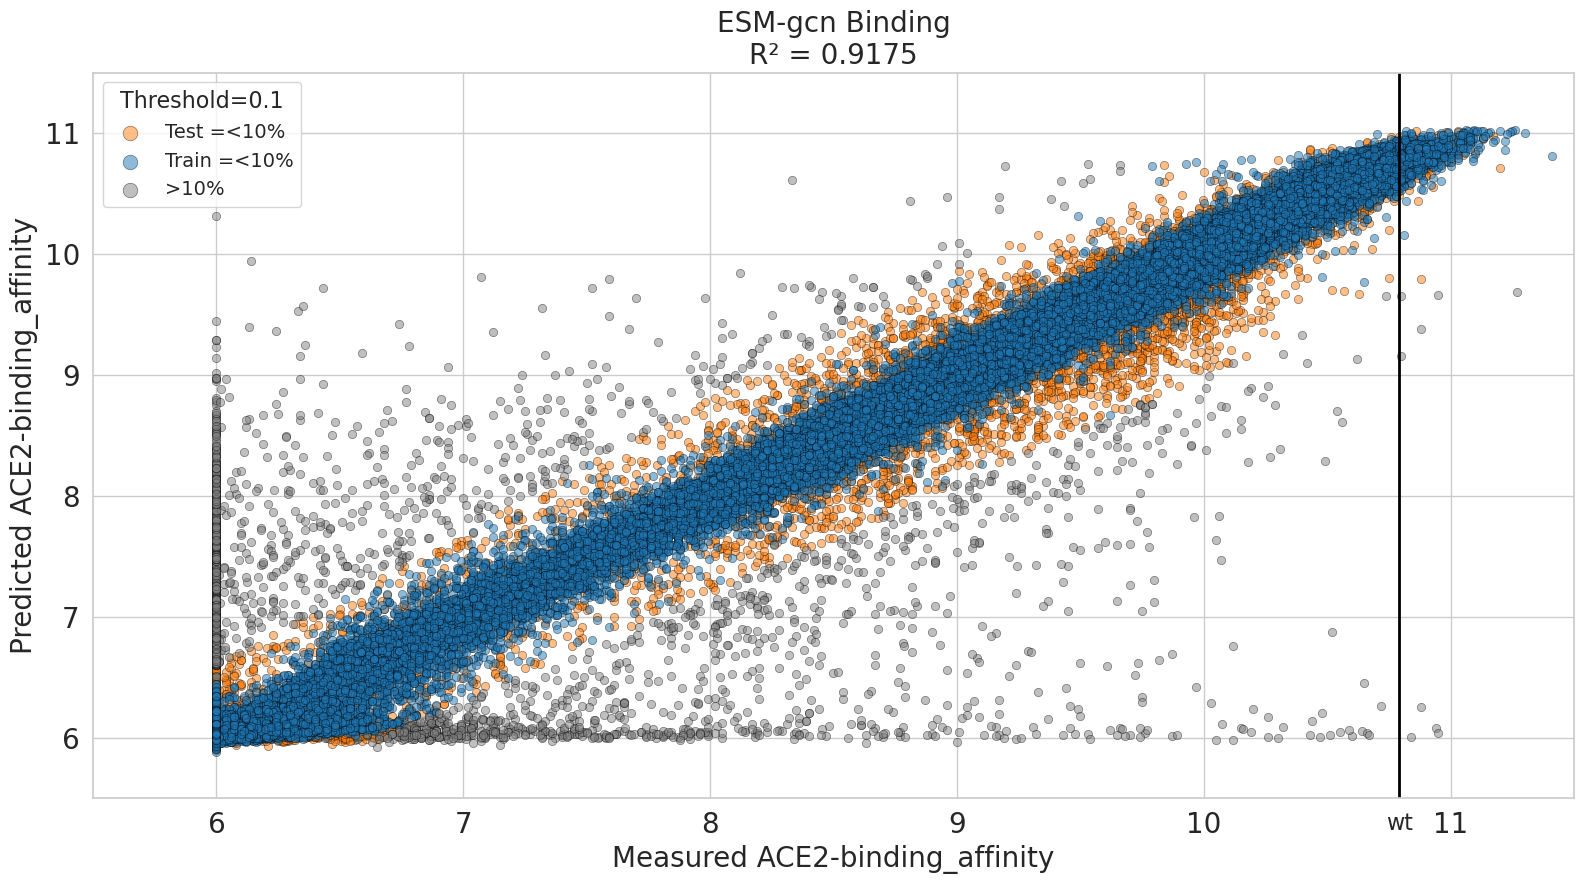

R^2: 0.897758513099847
R^2 outside of threshold: -0.3125675795365861
R^2 inside of threshold: 0.9251015016257746


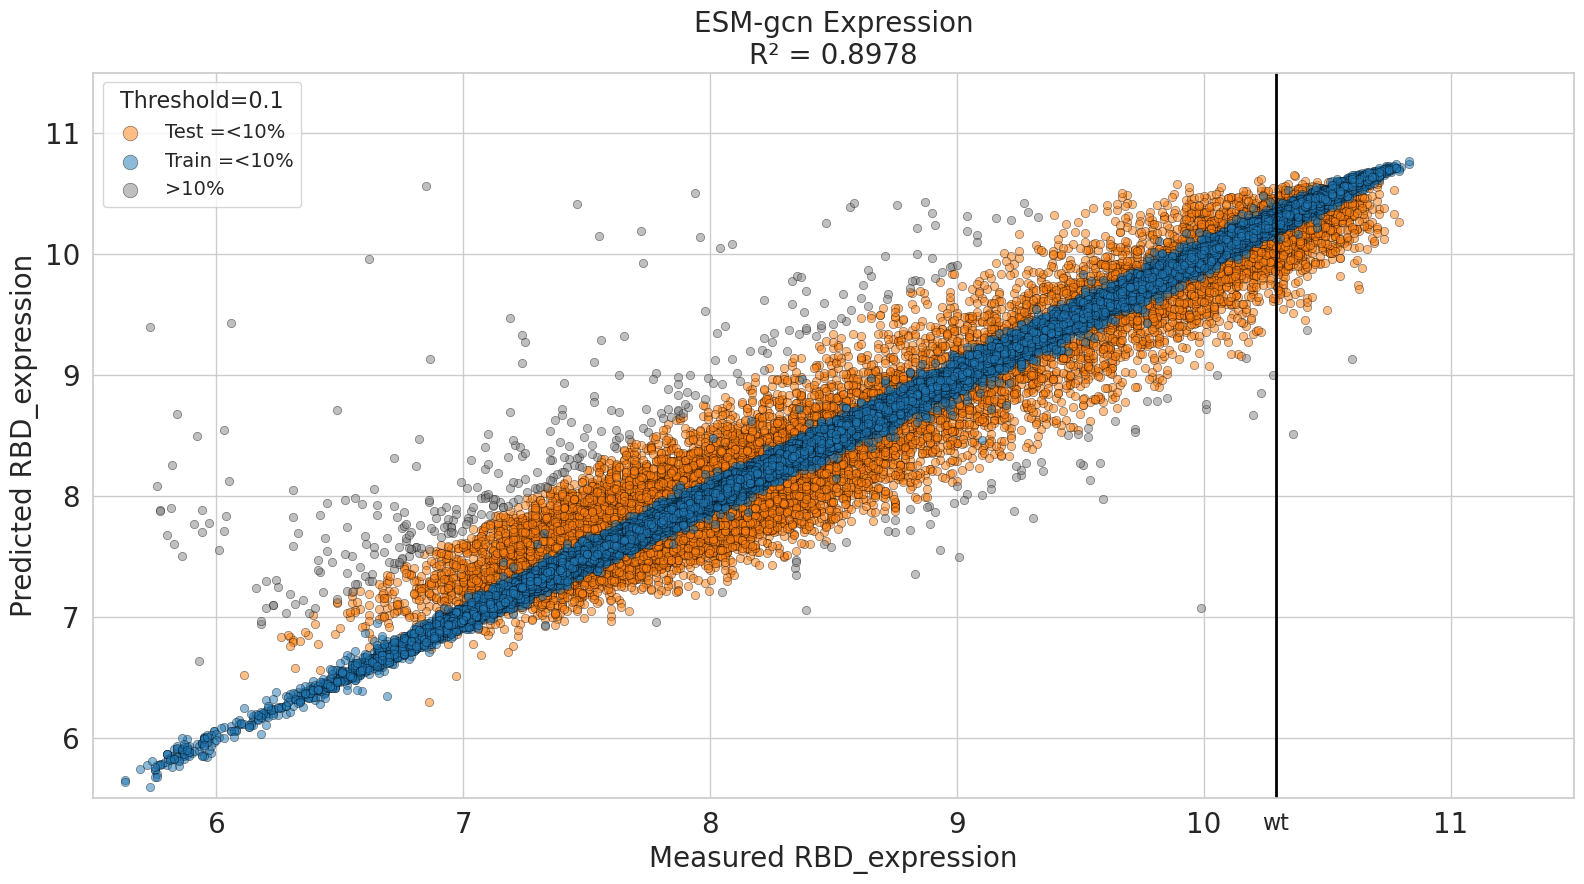

In [42]:
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/5_relu-adam.lr1e-04.esm_gcn-DMS_OLD-binding-2025-01-30_03-16/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_gcn_lr1e_04_binding = plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "predicted_value", "ESM-gcn Binding", "../../results/plots/measured_vs_predicted/scatter/esm_gcn/esm_gcn.lr1e-04.binding-scatter.pdf", binding_wt)

measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/5_relu-adam.lr1e-04.esm_gcn-DMS_OLD-expression-2025-01-30_03-14/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df ,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_gcn_lr1e_04_expression = plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "predicted_value", "ESM-gcn Expression", "../../results/plots/measured_vs_predicted/scatter/esm_gcn/esm_gcn.lr1e-04.expression-scatter.pdf", expression_wt)

### Non BE - LR = 1e-05

R^2: 0.9184787952555337
R^2 outside of threshold: -0.8234106188796757
R^2 inside of threshold: 0.9872566839477906


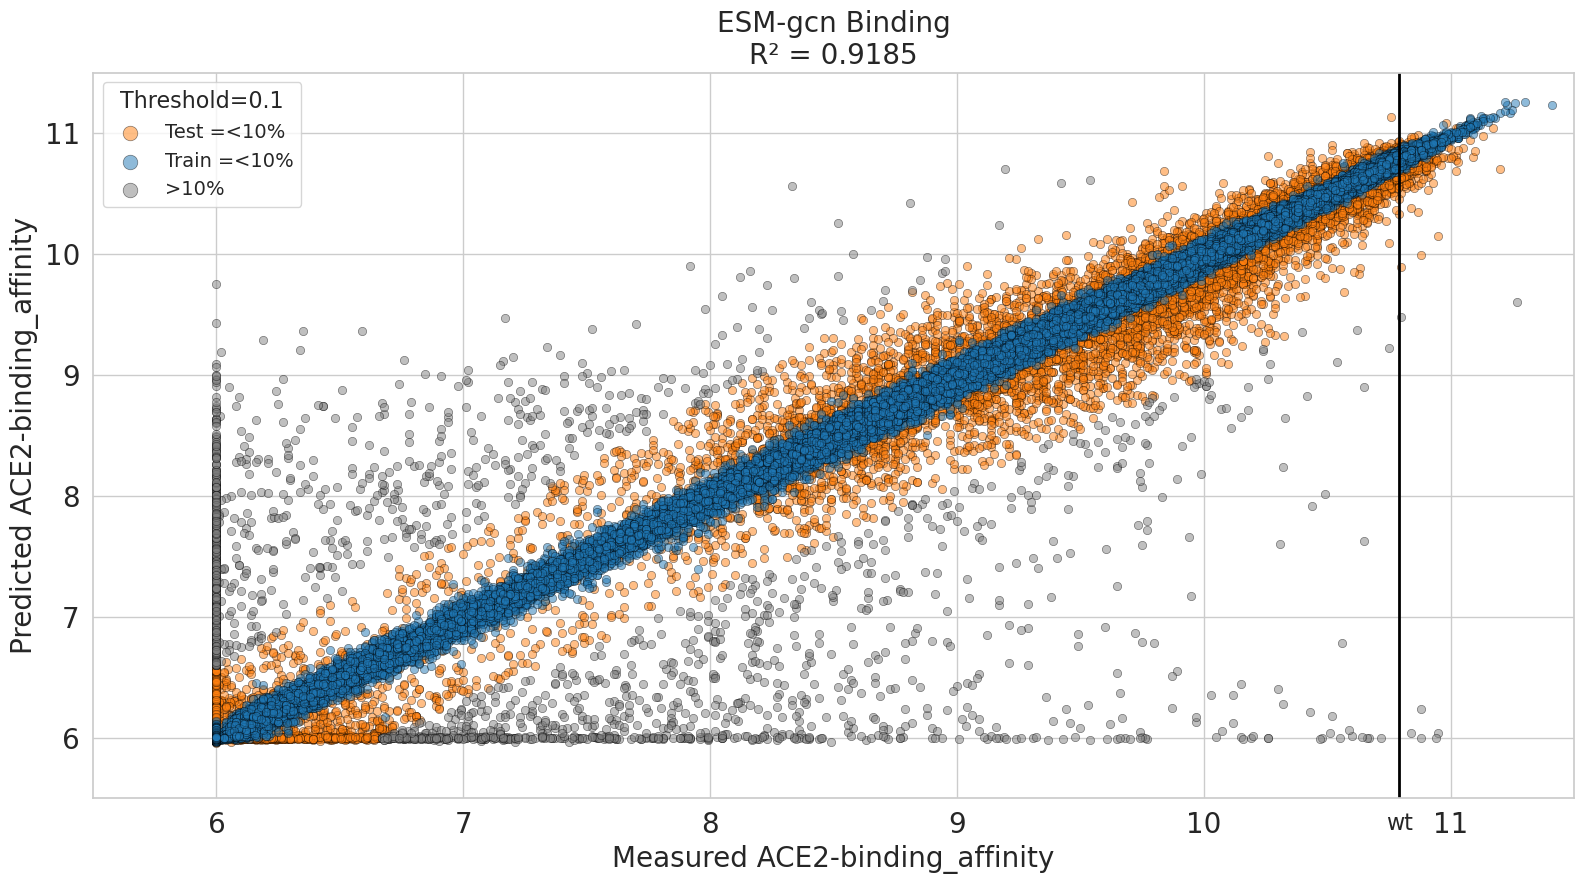

R^2: 0.8982035526253072
R^2 outside of threshold: -0.32316275687650453
R^2 inside of threshold: 0.9259635185274655


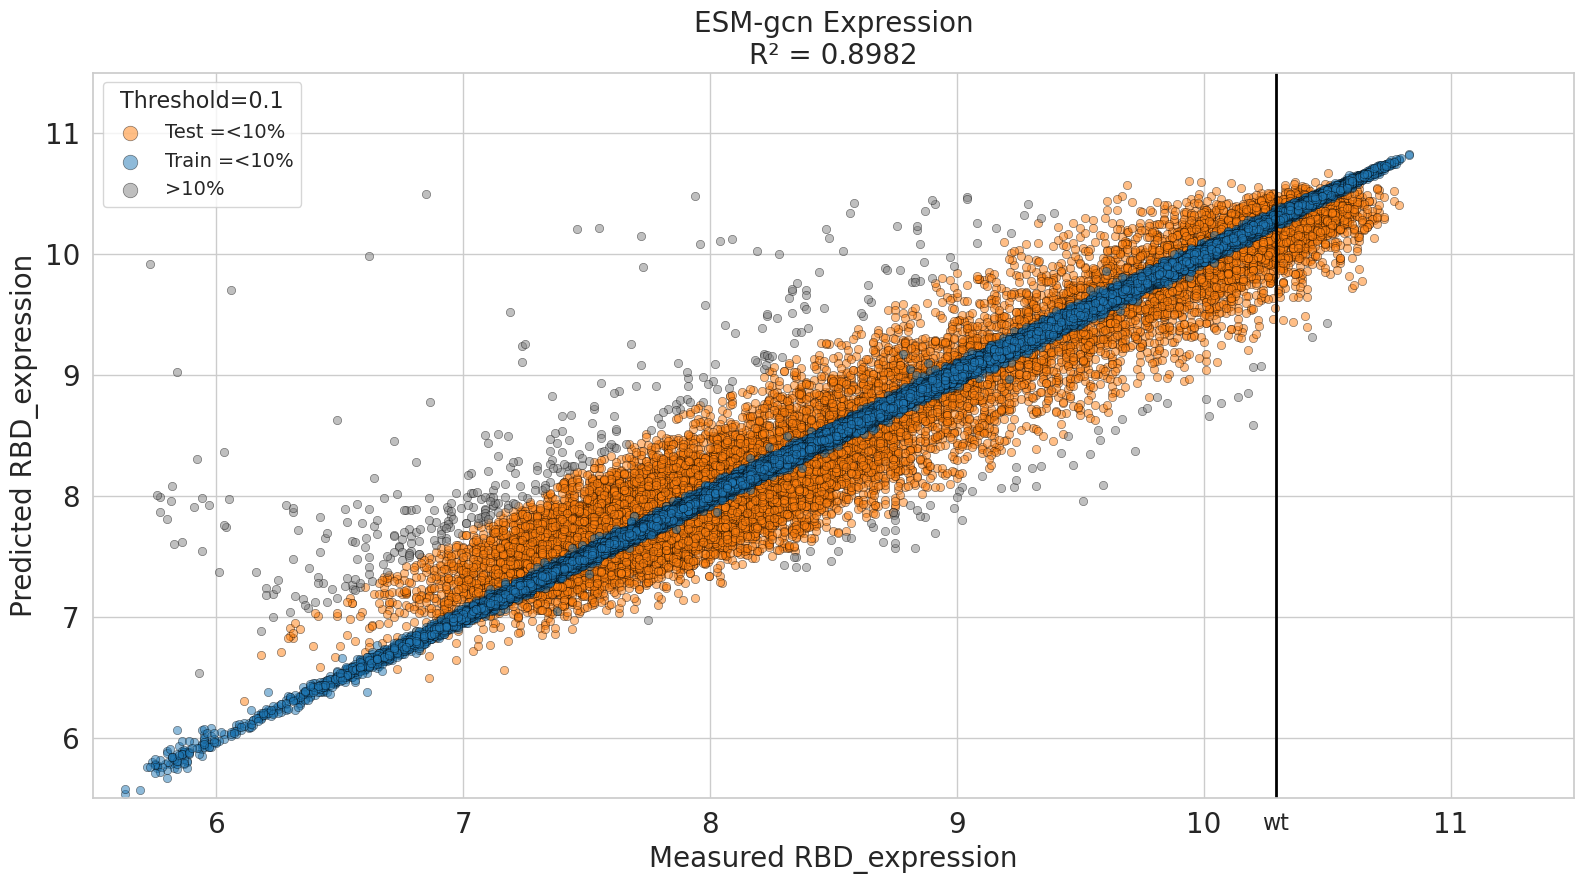

In [ ]:
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-29_11-28/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_gcn_lr1e_05_binding = plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "predicted_value", "ESM-gcn Binding", "../../results/plots/measured_vs_predicted/scatter/esm_gcn/esm_gcn.lr1e-05.binding-scatter.pdf", binding_wt)

measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-30_03-10/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df ,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_gcn_lr1e_05_expression = plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "predicted_value", "ESM-gcn Expression", "../../results/plots/measured_vs_predicted/scatter/esm_gcn/esm_gcn.lr1e-05.expression-scatter.pdf", expression_wt)

### BE - LR = 1e-04

R^2: 0.9217203586249945
R^2 outside of threshold: -0.9062605694031045
R^2 inside of threshold: 0.9883820180614685


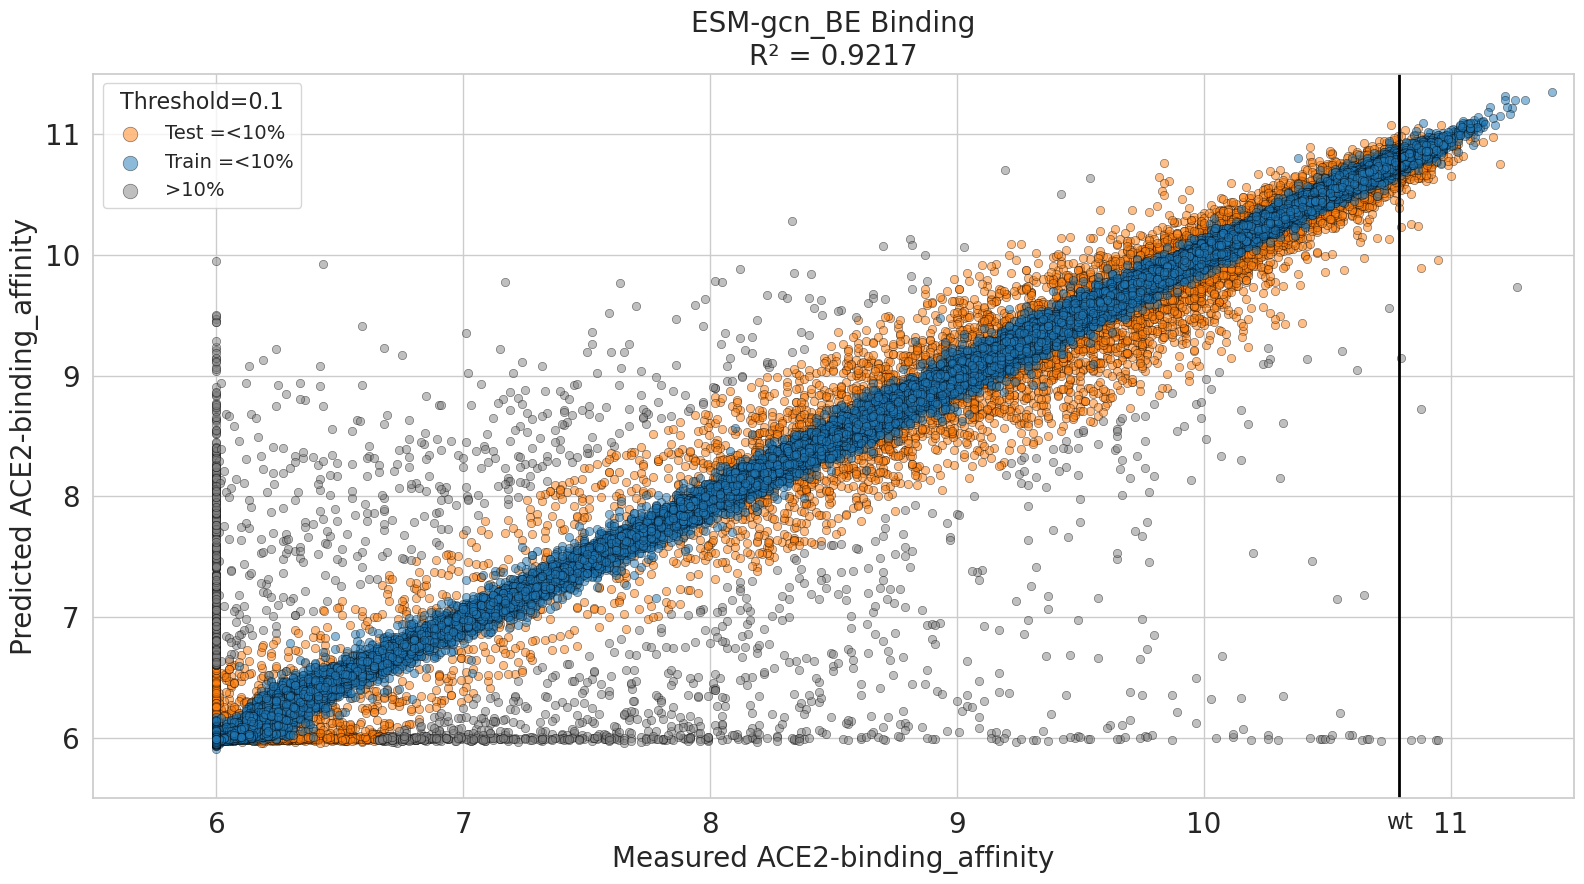

R^2: 0.8936175999041664
R^2 outside of threshold: -0.14810769357437237
R^2 inside of threshold: 0.9201800739115773


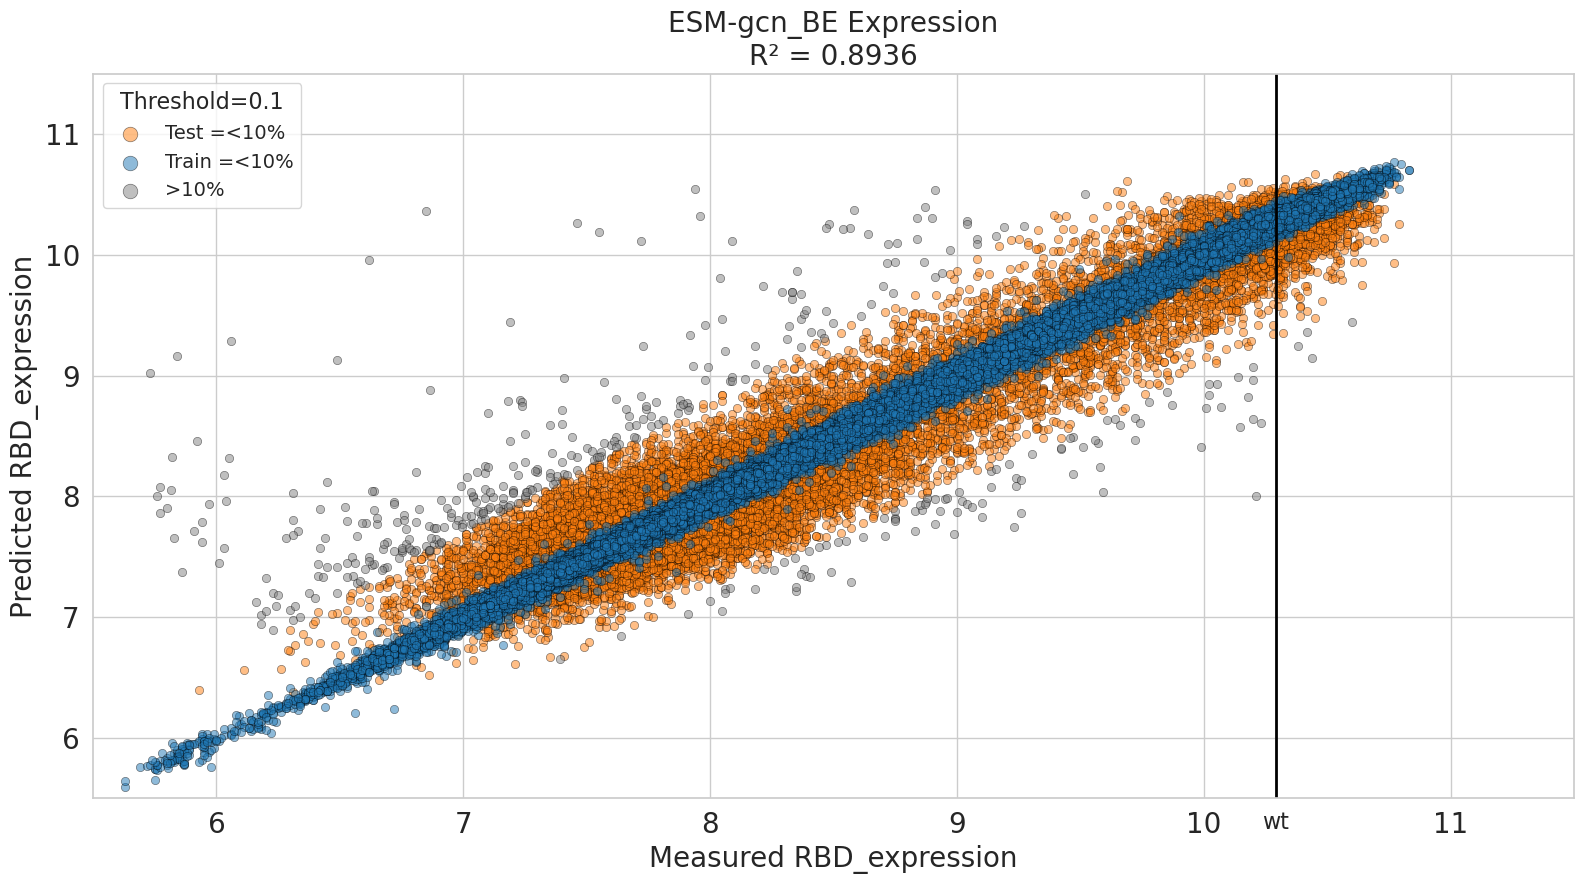

In [44]:
# All df are of length 102723
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/5_relu-adam.lr1e-04.esm_gcn_BE-DMS_OLD-2025-01-30_03-18/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_gcn_be_lr1e_04_binding = plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "binding_predicted_value", "ESM-gcn_BE Binding", "../../results/plots/measured_vs_predicted/scatter/esm_gcn/esm_gcn_be.lr1e-04.binding-scatter.pdf", binding_wt)
esm_gcn_be_lr1e_04_expression = plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "expression_predicted_value", "ESM-gcn_BE Expression", "../../results/plots/measured_vs_predicted/scatter/esm_gcn/esm_gcn_be.lr1e-04.expression-scatter.pdf", expression_wt)

### BE - LR = 1e-05

R^2: 0.9252464557369863
R^2 outside of threshold: -0.4388887002974067
R^2 inside of threshold: 0.9858587425617854


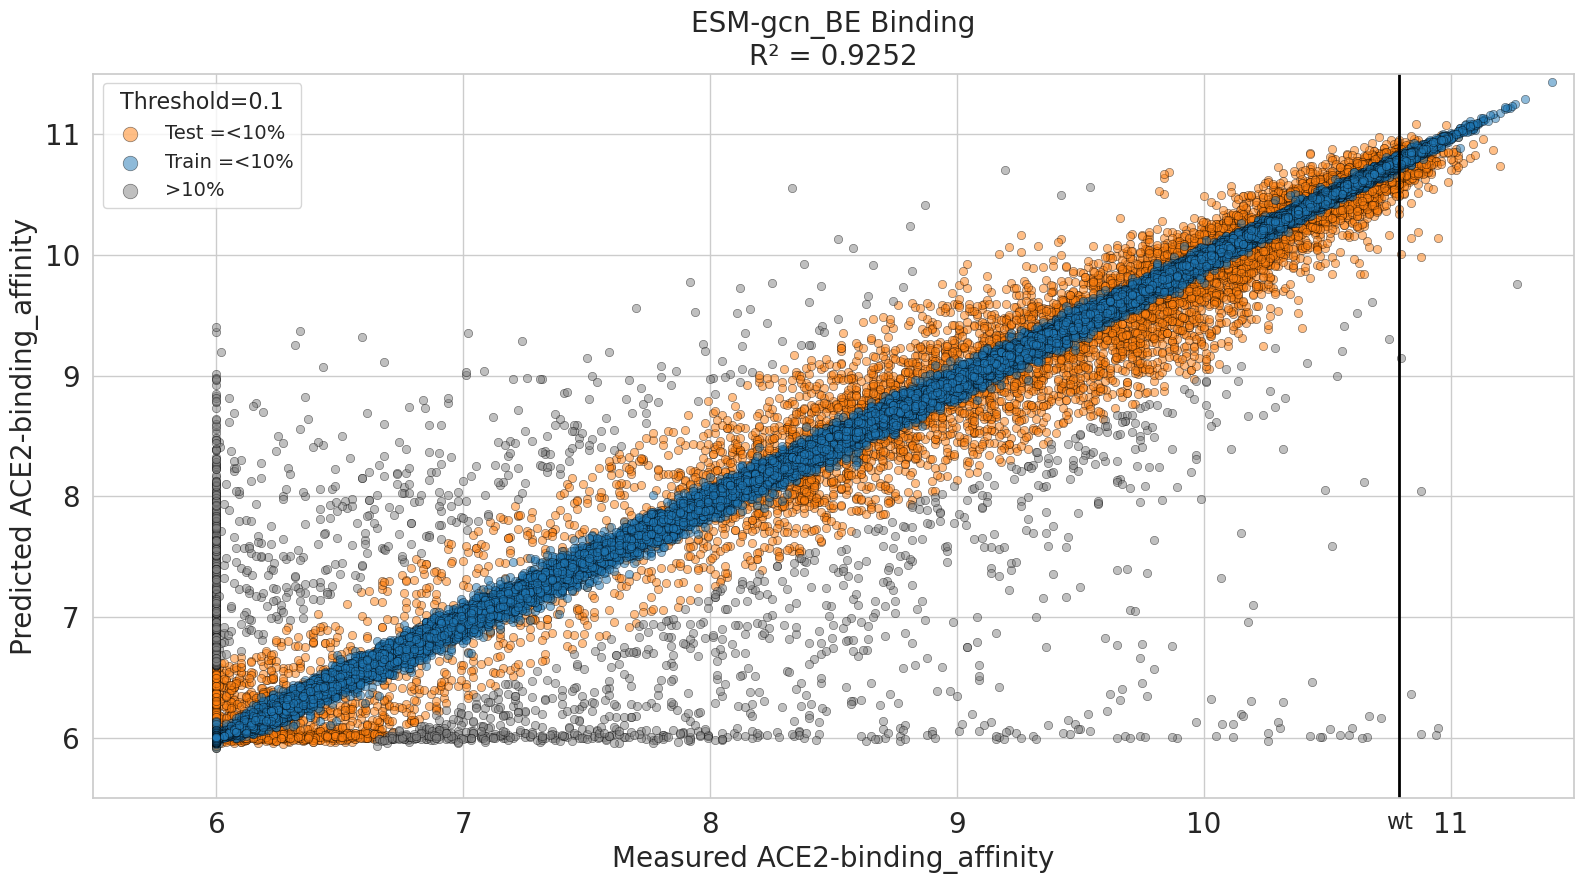

R^2: 0.8847221403592407
R^2 outside of threshold: -0.030344673607096917
R^2 inside of threshold: 0.9140595559123883


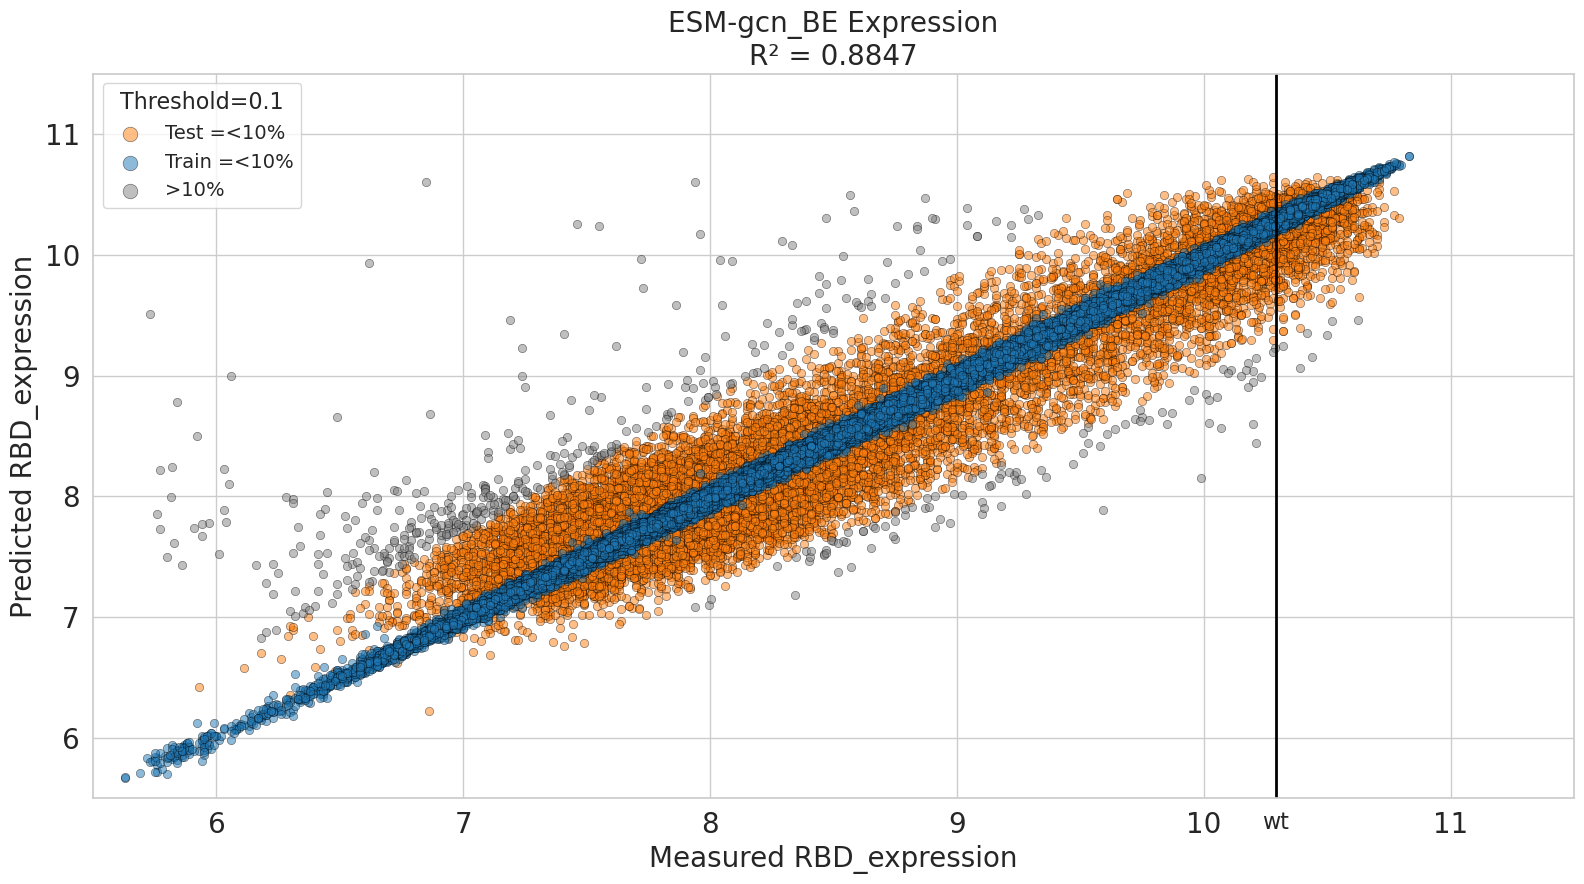

In [45]:
# All df are of length 102723
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn_BE-DMS_OLD-2025-01-30_03-17/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
esm_gcn_be_lr1e_05_binding = plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "binding_predicted_value", "ESM-gcn_BE Binding", "../../results/plots/measured_vs_predicted/scatter/esm_gcn/esm_gcn_be.lr1e-05.binding-scatter.pdf", binding_wt)
esm_gcn_be_lr1e_05_expression = plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "expression_predicted_value", "ESM-gcn_BE Expression", "../../results/plots/measured_vs_predicted/scatter/esm_gcn/esm_gcn_be.lr1e-05.expression-scatter.pdf", expression_wt)

---
## Bar Chart

In [46]:
r2_dict = {
    "Separate\nLR=1e-04.binding": esm_gcn_lr1e_04_binding,
    "Separate\nLR=1e-04.expression": esm_gcn_lr1e_04_expression,
    "Separate\nLR=1e-05.binding": esm_gcn_lr1e_05_binding,
    "Separate\nLR=1e-05.expression": esm_gcn_lr1e_05_expression,
    "Combined\nLR=1e-04.binding": esm_gcn_be_lr1e_04_binding,
    "Combined\nLR=1e-04.expression": esm_gcn_be_lr1e_04_expression,
    "Combined\nLR=1e-05.binding": esm_gcn_be_lr1e_05_binding,
    "Combined\nLR=1e-05.expression": esm_gcn_be_lr1e_05_expression
}
for key, value in r2_dict.items():
    print(f"{key}: {value}")

Separate
LR=1e-04.binding: 0.9174951942695192
Separate
LR=1e-04.expression: 0.897758513099847
Separate
LR=1e-05.binding: 0.9184787952555337
Separate
LR=1e-05.expression: 0.8982035526253072
Combined
LR=1e-04.binding: 0.9217203586249945
Combined
LR=1e-04.expression: 0.8936175999041664
Combined
LR=1e-05.binding: 0.9252464557369863
Combined
LR=1e-05.expression: 0.8847221403592407


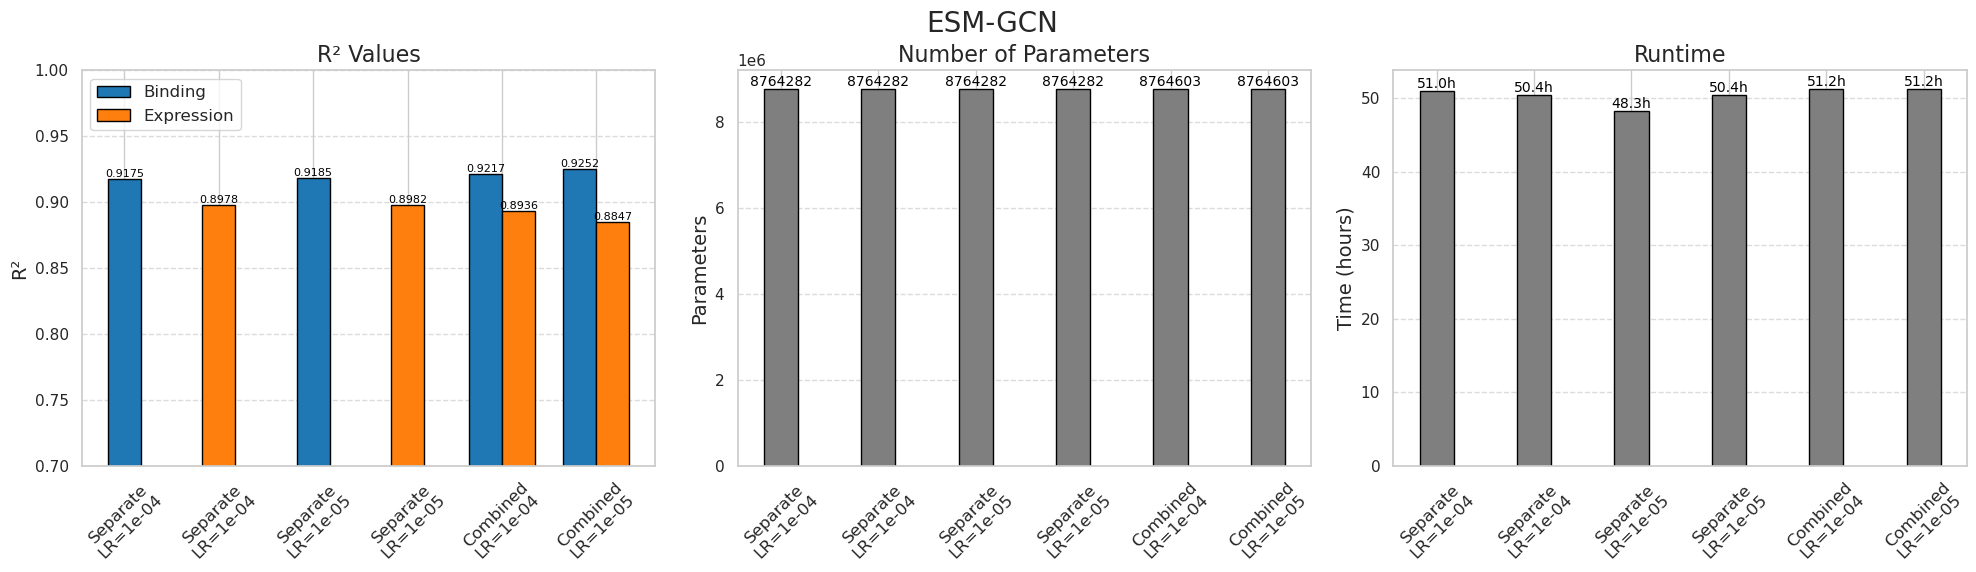

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# Data
r2_dict = {
    "Separate\nLR=1e-04.binding": 0.9174951942695192,
    "Separate\nLR=1e-04.expression":  0.897758513099847,
    "Separate\nLR=1e-05.binding": 0.9184787952555337,
    "Separate\nLR=1e-05.expression": 0.8982035526253072,
    "Combined\nLR=1e-04.binding": 0.9217203586249945,
    "Combined\nLR=1e-04.expression": 0.8936175999041664,
    "Combined\nLR=1e-05.binding": 0.9252464557369863,
    "Combined\nLR=1e-05.expression": 0.8847221403592407
}

params_dict = {
    "Separate\nLR=1e-04.binding": 8764282,
    "Separate\nLR=1e-04.expression": 8764282,
    "Separate\nLR=1e-05.binding": 8764282,
    "Separate\nLR=1e-05.expression": 8764282,
    "Combined\nLR=1e-04.binding": 8764603,
    "Combined\nLR=1e-04.expression": 8764603,
    "Combined\nLR=1e-05.binding": 8764603,
    "Combined\nLR=1e-05.expression": 8764603
}

runtime_dict = {
    "Separate\nLR=1e-04.binding": "51:00:28",
    "Separate\nLR=1e-04.expression": "50:26:05",
    "Separate\nLR=1e-05.binding": "48:16:27",
    "Separate\nLR=1e-05.expression": "50:26:24",
    "Combined\nLR=1e-04.binding": "51:11:18",
    "Combined\nLR=1e-04.expression": "51:11:18",
    "Combined\nLR=1e-05.binding": "51:10:52",
    "Combined\nLR=1e-05.expression": "51:10:52"
}

def parse_extended_time(time_str):
    hours, minutes, seconds = map(int, time_str.split(':'))
    td = timedelta(hours=hours, minutes=minutes, seconds=seconds)
    return td.total_seconds() / 3600  # Convert to hours

# Convert runtime dictionary to hours
runtime_hours = {k: parse_extended_time(v) for k, v in runtime_dict.items()}

# Separate models and combined models
separate_models = sorted([k for k in r2_dict.keys() if "Separate" in k])
combined_models = sorted(list(set([k.rsplit(".", 1)[0] for k in r2_dict.keys() if "Combined" in k])))

# X indices
x_inds_sep = np.arange(len(separate_models))
x_inds_comb = np.arange(len(combined_models)) + len(separate_models)

# Bar width
bar_width = 0.35

# Colors
binding_color = 'tab:blue'
expression_color = 'tab:orange'

# Figure setup
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# R² Plot
binding_legend = None
expression_legend = None

for i, model in enumerate(separate_models):
    color = binding_color if 'binding' in model else expression_color
    bar = axes[0].bar(x_inds_sep[i], r2_dict[model], color=color, edgecolor='black', width=bar_width)
    if 'binding' in model and binding_legend is None:
        binding_legend = bar
    elif 'expression' in model and expression_legend is None:
        expression_legend = bar

for i, model in enumerate(combined_models):
    binding_r2 = r2_dict[f"{model}.binding"]
    expression_r2 = r2_dict[f"{model}.expression"]
    axes[0].bar(x_inds_comb[i] - bar_width/2, binding_r2, color=binding_color, edgecolor='black', width=bar_width)
    axes[0].bar(x_inds_comb[i] + bar_width/2, expression_r2, color=expression_color, edgecolor='black', width=bar_width)

axes[0].set_title("R² Values", fontsize=16)
axes[0].set_ylabel("R²", fontsize=14)
axes[0].set_ylim(0.7, 1.0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend([binding_legend, expression_legend], ["Binding", "Expression"], fontsize=12, loc="upper left")

# Parameters Plot
params_sep = [params_dict[m] for m in separate_models]
params_comb = [params_dict[f"{m}.binding"] for m in combined_models]

axes[1].bar(x_inds_sep, params_sep, color='tab:grey', edgecolor='black', width=bar_width)
axes[1].bar(x_inds_comb, params_comb, color='tab:grey', edgecolor='black', width=bar_width)
axes[1].set_title("Number of Parameters", fontsize=16)
axes[1].set_ylabel("Parameters", fontsize=14)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Runtime Plot
runtime_sep = [runtime_hours[m] for m in separate_models]
runtime_comb = [runtime_hours[f"{m}.binding"] for m in combined_models]

axes[2].bar(x_inds_sep, runtime_sep, color='tab:grey', edgecolor='black', width=bar_width)
axes[2].bar(x_inds_comb, runtime_comb, color='tab:grey', edgecolor='black', width=bar_width)
axes[2].set_title("Runtime", fontsize=16)
axes[2].set_ylabel("Time (hours)", fontsize=14)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Common x-axis labels
all_labels = separate_models + combined_models
all_labels = [label.replace('.binding', '').replace('.expression', '') for label in all_labels]
for ax in axes:
    ax.set_xticks(list(x_inds_sep) + list(x_inds_comb))
    ax.set_xticklabels(all_labels, fontsize=12, rotation=45)

# Add value labels on bars
for ax in axes:
    for bar in ax.patches:
        height = bar.get_height()
        if ax == axes[2]:  # Runtime plot
            ax.text(bar.get_x() + bar.get_width()/2.0, height, f'{height:.1f}h',
                   ha='center', va='bottom', fontsize=10, color='black')
        elif ax == axes[1]:  # Parameter plot
            ax.text(bar.get_x() + bar.get_width()/2.0, height, f'{height}',
                   ha='center', va='bottom', fontsize=10, color='black')
        else: # R2 plot
            ax.text(bar.get_x() + bar.get_width()/2.0, height, f'{height:.4f}',
                   ha='center', va='bottom', fontsize=8, color='black')
            
fig.suptitle("ESM-GCN", fontsize=20, y=.95)
plt.tight_layout()

save_as = "../../results/plots/measured_vs_predicted/bar/esm_gcn-bar_comp.pdf"
plt.savefig(save_as, format='pdf')
plt.savefig(save_as.replace('.pdf', '.png'), format='png')

---
## ESM-GCN vs ESM-GCN_BE

In [48]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Best test loss epoch
def find_best_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    best_epoch = df.loc[df[rmse_column].idxmin()]
    return int(best_epoch['Epoch']), best_epoch[rmse_column]

# Last epoch
def find_last_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    last_epoch = df.iloc[-1]
    return int(last_epoch['Epoch']), last_epoch[rmse_column]

def plot_comparative_log_file(metrics_csv_be, metrics_csv_b, metrics_csv_e, coords, metrics_img):
    df_be = pd.read_csv(metrics_csv_be)
    df_b = pd.read_csv(metrics_csv_b)
    df_e = pd.read_csv(metrics_csv_e)

    sns.set_theme(style="darkgrid")
    fig, ((ax_tr_be, ax_tr), (ax_te_be, ax_te)) = plt.subplots(2, 2, figsize=(16, 9))  # 1 rows, 2 columns
    fontsize = 16

    # Plot 1: Training BE Metrics
    ax_tr_be.plot(df_be['Epoch'], df_be[f'Train Binding RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_tr_be.plot(df_be['Epoch'], df_be[f'Train Expression RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_tr_be.tick_params(axis='x', bottom=False, labelbottom=False)    
    ax_tr_be.set_xlim(-50, 1050)
    ax_tr_be.set_ylabel('RMSE', fontsize=fontsize)
    ax_tr_be.tick_params(axis='y', labelsize=fontsize)
    ax_tr_be.set_ylim(-0.1, 1.3)
    ax_tr_be.legend(title='Training (Combined)', loc='upper right', frameon=False)

    # Plot 2: Testing BE Metrics
    ax_te_be.plot(df_be['Epoch'], df_be[f'Test Binding RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_te_be.plot(df_be['Epoch'], df_be[f'Test Expression RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_te_be.set_xlabel('Epochs', fontsize=fontsize)
    ax_te_be.tick_params(axis='x', labelsize=fontsize)
    ax_te_be.set_xlim(-50, 1050)
    ax_te_be.set_ylabel('RMSE', fontsize=fontsize)
    ax_te_be.tick_params(axis='y', labelsize=fontsize)
    ax_te_be.set_ylim(-0.1, 1.3)
    ax_te_be.legend(title='Testing (Combined)', loc='upper right', frameon=False)

    # Plot 3: Training Metrics
    ax_tr.plot(df_b['Epoch'], df_b[f'Train RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_tr.plot(df_e['Epoch'], df_e[f'Train RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_tr.tick_params(axis='x', bottom=False, labelbottom=False)   
    ax_tr.set_xlim(-50, 1050)
    ax_tr.tick_params(axis='y', left=False, labelleft=False)
    ax_tr.set_ylim(-0.1, 1.3)
    ax_tr.legend(title='Training (Separate)', loc='upper right', frameon=False)

    # Plot 4: Testing Metrics
    ax_te.plot(df_b['Epoch'], df_b[f'Test RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_te.plot(df_e['Epoch'], df_e[f'Test RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_te.set_xlabel('Epochs', fontsize=fontsize)
    ax_te.tick_params(axis='x', labelsize=fontsize)
    ax_te.set_xlim(-50, 1050)
    ax_te.tick_params(axis='y', left=False, labelleft=False)
    ax_te.set_ylim(-0.1, 1.3)
    ax_te.legend(title='Testing (Separate)', loc='upper right', frameon=False)

    # Plot Best Test Loss
    best_df_be_b_rmse = find_best_epoch(metrics_csv_be, f'Test Binding RMSE')
    best_df_be_e_rmse = find_best_epoch(metrics_csv_be, f'Test Expression RMSE')
    best_df_b_rmse = find_best_epoch(metrics_csv_b, f'Test RMSE')
    best_df_e_rmse = find_best_epoch(metrics_csv_e, f'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"\tBE Binding: epoch {best_df_be_b_rmse[0]}, rmse {best_df_be_b_rmse[1]:.4f}")
    print(f"\tBE Expression: epoch {best_df_be_e_rmse[0]}, rmse {best_df_be_e_rmse[1]:.4f}")
    print(f"\tBinding: epoch {best_df_b_rmse[0]}, rmse {best_df_b_rmse[1]:.4f}")
    print(f"\tExpression: epoch {best_df_e_rmse[0]}, rmse {best_df_e_rmse[1]:.4f}")

    ax_te_be.annotate(
        f'({best_df_be_b_rmse[0]}, {best_df_be_b_rmse[1]:.4f})', best_df_be_b_rmse, 
        textcoords="offset points", xytext=(coords['BE Binding']), ha='center', va='top', color='tab:blue', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax_te_be.annotate(
        f'({best_df_be_e_rmse[0]}, {best_df_be_e_rmse[1]:.4f})', best_df_be_e_rmse, 
        textcoords="offset points", xytext=(coords['BE Expression']), ha='center', va='top', color='tab:orange', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax_te.annotate(
        f'({best_df_b_rmse[0]}, {best_df_b_rmse[1]:.4f})', best_df_b_rmse, 
        textcoords="offset points", xytext=(coords['Binding']), ha='center', va='top', color='tab:blue', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax_te.annotate(
        f'({best_df_e_rmse[0]}, {best_df_e_rmse[1]:.4f})', best_df_e_rmse, 
        textcoords="offset points", xytext=(coords['Expression']), ha='center', va='top', color='tab:orange', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

1e-04

Best test RMSE at epoch x:
	BE Binding: epoch 92, rmse 0.5292
	BE Expression: epoch 863, rmse 0.3166
	Binding: epoch 84, rmse 0.5478
	Expression: epoch 215, rmse 0.3189


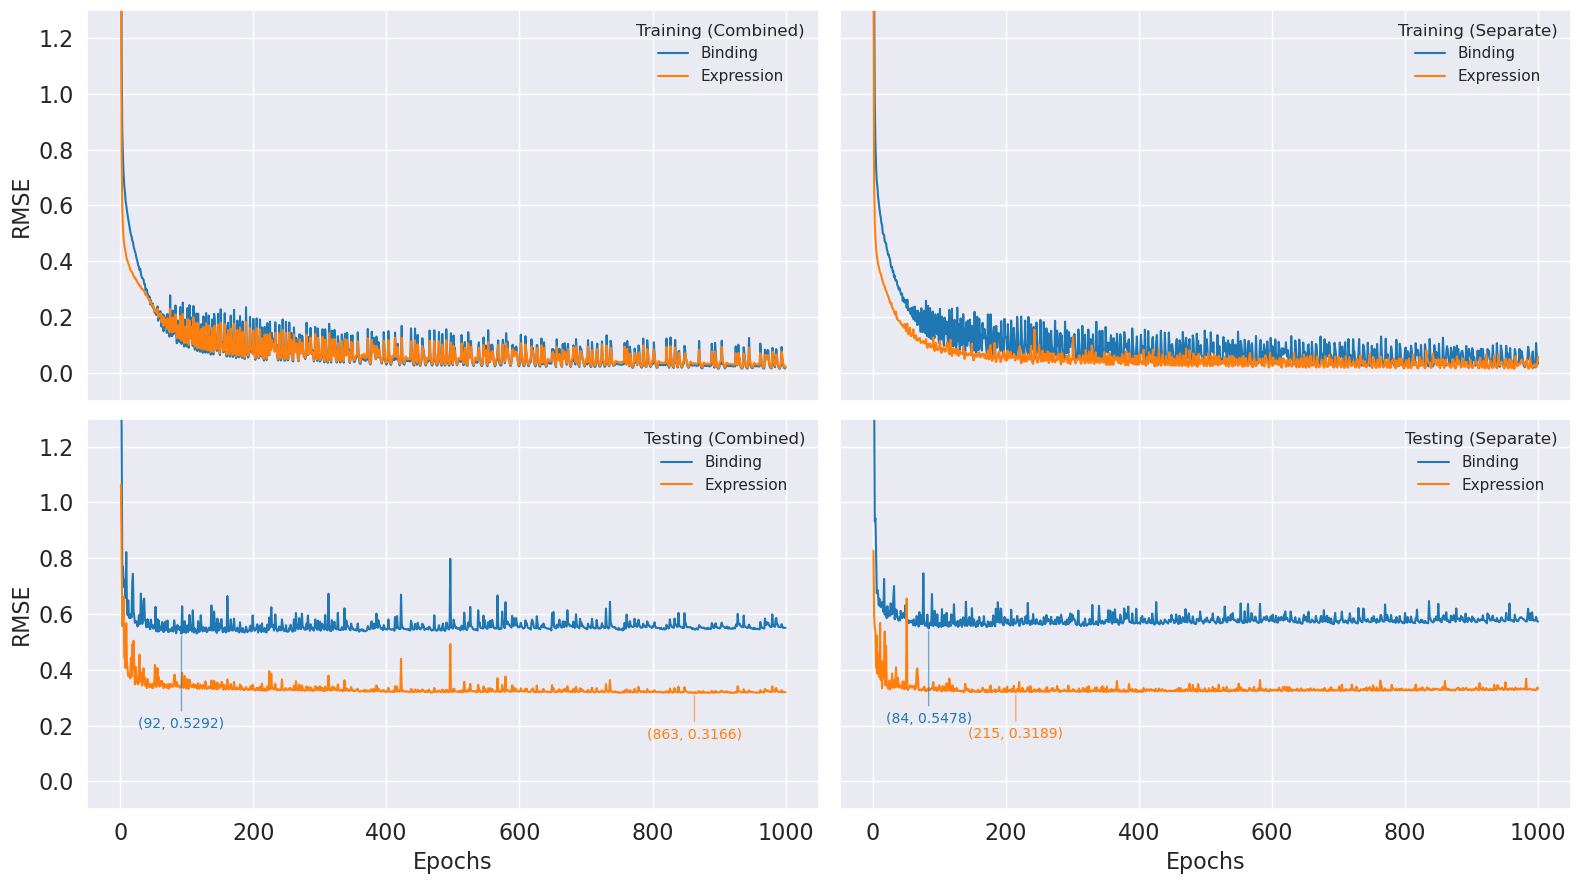

In [49]:
be_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/5_relu-adam.lr1e-04.esm_gcn_BE-DMS_OLD-2025-01-30_03-18/esm_gcn_BE-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/5_relu-adam.lr1e-04.esm_gcn-DMS_OLD-binding-2025-01-30_03-16/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/5_relu-adam.lr1e-04.esm_gcn-DMS_OLD-expression-2025-01-30_03-14/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
 
coords = {
    "BE Binding": (0,-60),
    "BE Expression": (0,-25),
    "Binding": (0,-60),
    "Expression": (0,-25)
}

comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/1e-04.best_esm-gcn_BE.vs.best_esm-gcn"
plot_comparative_log_file(be_adam_lr_1e_neg_4, b_adam_lr_1e_neg_4, e_adam_lr_1e_neg_4, coords, f"{comparison_file}.model_comp.pdf")

1e-05

Best test RMSE at epoch x:
	BE Binding: epoch 750, rmse 0.5207
	BE Expression: epoch 982, rmse 0.3374
	Binding: epoch 837, rmse 0.5445
	Expression: epoch 978, rmse 0.3182


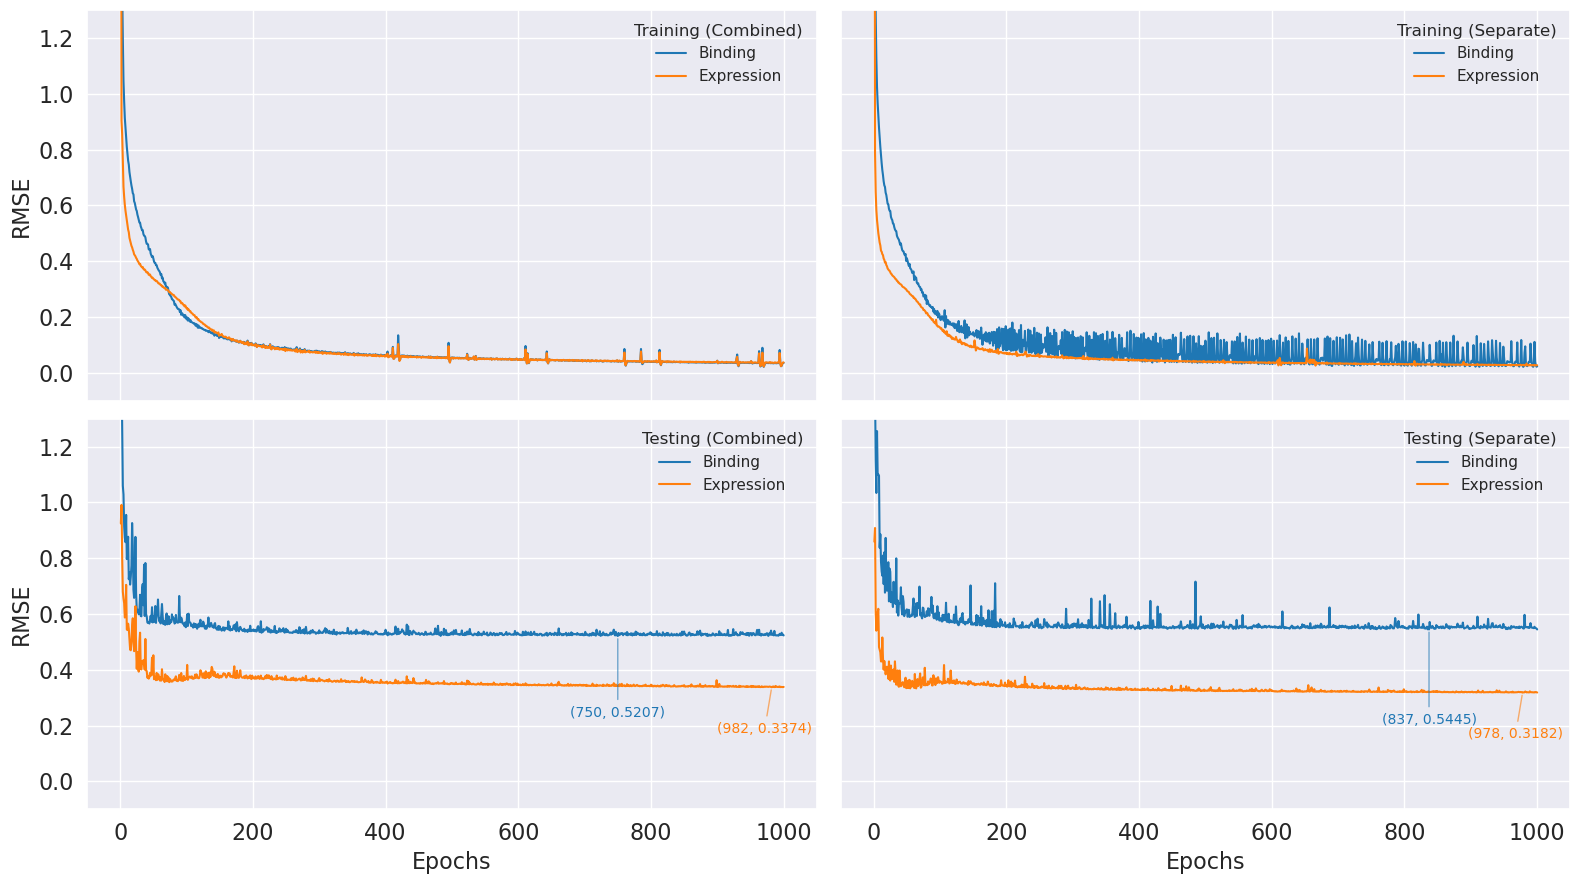

In [50]:
be_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn_BE-DMS_OLD-2025-01-30_03-17/esm_gcn_BE-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-29_11-28/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/5_relu-adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-30_03-10/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"

coords = {
    "BE Binding": (0,-50),
    "BE Expression": (-5,-25),
    "Binding": (0,-60),
    "Expression": (-5,-25)
}

comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/1e-05.best_esm-gcn_BE.vs.best_esm-gcn"
plot_comparative_log_file(be_adam_lr_1e_neg_5, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
## Frequent Mutations
Histogram figure of frequent mutations for ESM-GCN_BE. We'll choose this model because it was the best performing for both binding and expression.

In [1]:
import pandas as pd

# All df are of length 102723
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0)
predicted_df = pd.read_csv("../../results/run_results/esm_gcn/5_relu-adam.lr1e-04.esm_gcn_BE-DMS_OLD-2025-01-30_03-18/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
predicted_df.rename(columns={'predicted_value': 'binding_predicted_value'}, inplace=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
merged_df.head(5)

,seq_id,binding_predicted_value,expression_predicted_value,mode,target,sequence,ACE2-binding_affinity,RBD_expression
0,SARS-CoV-2-S19E_E141G_N157A,5.980326,8.163260,train,SARS-CoV-2,NITNLCPFGEVFNATRFAEVYAWNRKRISNCVADYSVLYNSASFST...,6.00,8.17
1,SARS-CoV-2-T63F_Y178V_S184L,9.150980,8.125720,train,SARS-CoV-2,NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFST...,9.16,8.11
2,SARS-CoV-2-W106A_G146C,5.996279,7.539367,train,SARS-CoV-2,NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFST...,6.00,7.59
3,SARS-CoV-2-A18C_R25V_L122T_P149R,6.099906,8.362879,train,SARS-CoV-2,NITNLCPFGEVFNATRFCSVYAWNVKRISNCVADYSVLYNSASFST...,6.13,8.42
4,SARS-CoV-2-D59W_P96S,10.157553,8.087464,train,SARS-CoV-2,NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFST...,10.16,8.02


### Binding

In [2]:
# Binding
binding_df = merged_df[["seq_id", "binding_predicted_value", "ACE2-binding_affinity", "mode"]].copy()
binding_df["percentage_error"] = ((merged_df["binding_predicted_value"] - merged_df["ACE2-binding_affinity"]) / merged_df["ACE2-binding_affinity"]) * 100
binding_df.head(5)

,seq_id,binding_predicted_value,ACE2-binding_affinity,mode,percentage_error
0,SARS-CoV-2-S19E_E141G_N157A,5.980326,6.00,train,-0.327905
1,SARS-CoV-2-T63F_Y178V_S184L,9.150980,9.16,train,-0.098472
2,SARS-CoV-2-W106A_G146C,5.996279,6.00,train,-0.062021
3,SARS-CoV-2-A18C_R25V_L122T_P149R,6.099906,6.13,train,-0.490923
4,SARS-CoV-2-D59W_P96S,10.157553,10.16,train,-0.024087


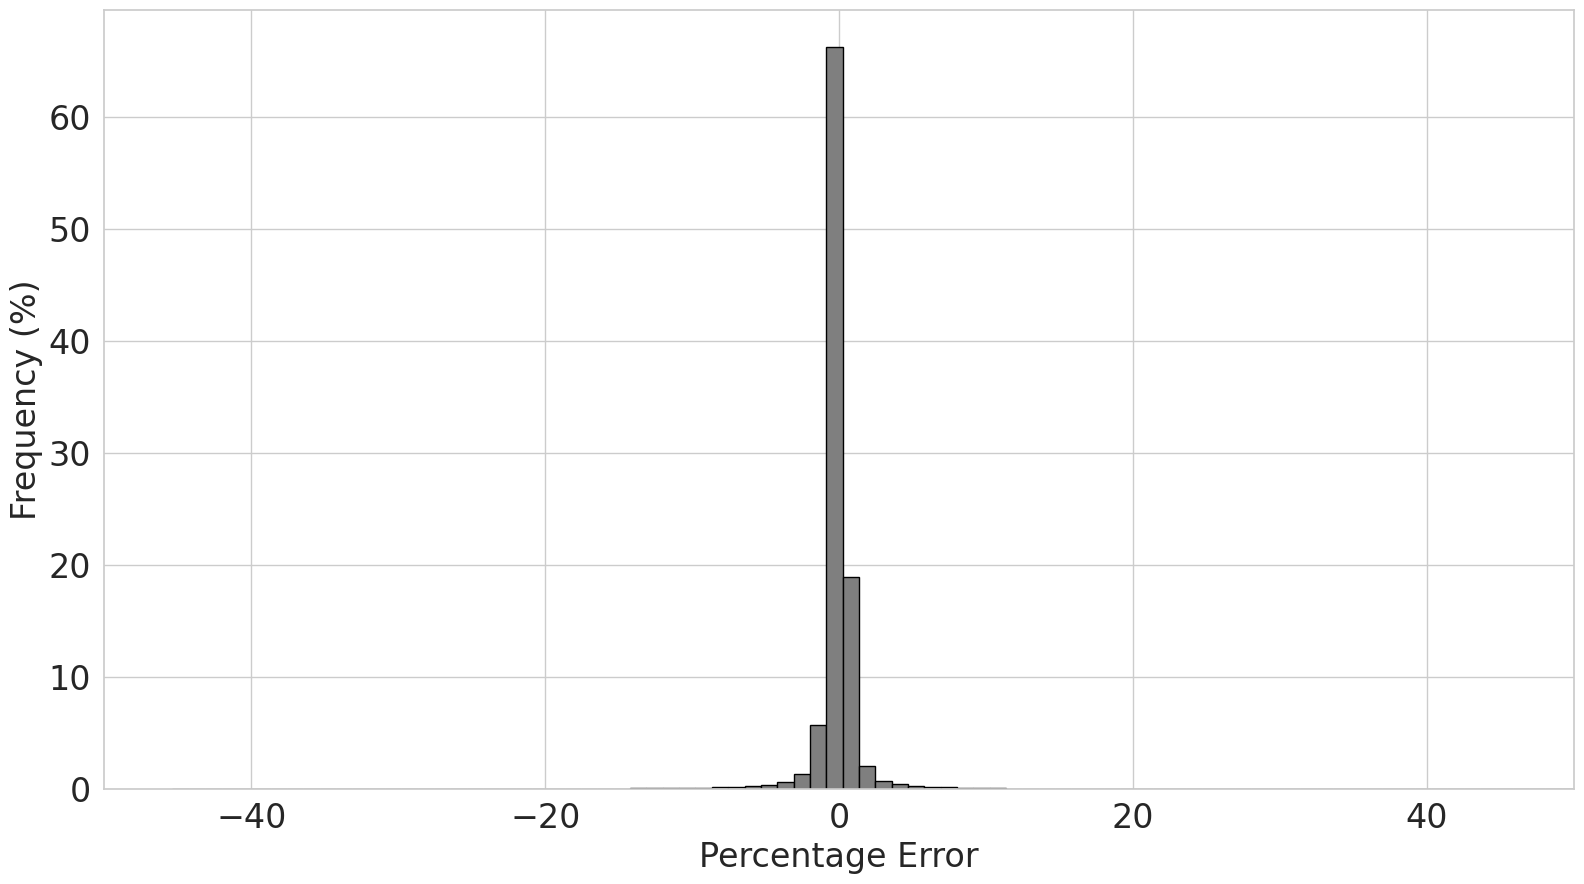

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 9))
plt.hist(
    binding_df["percentage_error"], 
    bins=100, 
    weights=[100 / len(binding_df)] * len(binding_df), 
    edgecolor='black', 
    color='tab:grey'
)

fontsize = 24
plt.xlim(-50, 50)  
plt.xlabel("Percentage Error", fontsize=fontsize)
plt.ylabel("Frequency (%)", fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.tight_layout()

save_as = "../../results/plots/measured_vs_predicted/bar/esm_gcn_BE.lr1e-04.binding-percent_error_histogram.pdf"
plt.savefig(save_as, format='pdf')
plt.savefig(save_as.replace('.pdf', '.png'), format='png')

Now let's pull the outliers from top and bottom 2.5%.

In [4]:
lower_bound = binding_df['percentage_error'].quantile(0.025)
upper_bound = binding_df['percentage_error'].quantile(0.975)

outliers = binding_df[(binding_df['percentage_error'] < lower_bound) | (binding_df['percentage_error'] > upper_bound)].reset_index(drop=True)
outliers.head(5)

,seq_id,binding_predicted_value,ACE2-binding_affinity,mode,percentage_error
0,SARS-CoV-2-F12V_I28W_K48Y_F99G_P149F_F156T,7.548138,7.30,train,3.399146
1,SARS-CoV-2-Y21F_Q84S_K94A_N107T,6.465226,6.27,train,3.113647
2,SARS-CoV-2-P82S_D97L,7.986299,8.38,train,-4.698108
3,SARS-CoV-2-N30I_P96G_G116S_P161Y_A192S,6.134600,6.37,train,-3.695452
4,SARS-CoV-2-L5T_A14Y_A22H_C158W_T201M,6.024191,6.28,train,-4.073393


We need to adjust the seq_id to acquire the mutations from the data. 

The Spike receptor binding domain (RBD) from SARS-CoV-2 (isolate Wuhan-Hu-1, GenBank : MN908947, residues N331-T531) (checked [Deep Mutational Scanning of SARS-CoV-2 Receptor Binding Domain Reveals Constraints on Folding and ACE2 Binding](https://www.cell.com/cell/fulltext/S0092-8674(20)31003-5?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0092867420310035%3Fshowall%3Dtrue)). So we need to add 330 to get the RBD site (data not 0 indexed).

In [5]:
df = outliers.copy()
df['target'] = df['seq_id'].str.rsplit('-', n=1).str[0]
df['aa_substitutions'] = df['seq_id'].str.rsplit('-', n=1).str[1].str.rsplit('_')
print(len(df))

df = df.explode('aa_substitutions')
print(len(df))

df['RBD_mutation_site'] = df['aa_substitutions'].str.extract(r'(\d+)').astype(int) + 330 # Extract numeric site, RBD site
df['original_aa'] = df['aa_substitutions'].str[0]
df['new_aa'] = df['aa_substitutions'].str[-1]
df['aa_sub'] = df['original_aa'] + ">" + df['new_aa']
df.head(5)

5138
16888


,seq_id,binding_predicted_value,ACE2-binding_affinity,mode,percentage_error,target,aa_substitutions,RBD_mutation_site,original_aa,new_aa,aa_sub
0,SARS-CoV-2-F12V_I28W_K48Y_F99G_P149F_F156T,7.548138,7.3,train,3.399146,SARS-CoV-2,F12V,342,F,V,F>V
0,SARS-CoV-2-F12V_I28W_K48Y_F99G_P149F_F156T,7.548138,7.3,train,3.399146,SARS-CoV-2,I28W,358,I,W,I>W
0,SARS-CoV-2-F12V_I28W_K48Y_F99G_P149F_F156T,7.548138,7.3,train,3.399146,SARS-CoV-2,K48Y,378,K,Y,K>Y
0,SARS-CoV-2-F12V_I28W_K48Y_F99G_P149F_F156T,7.548138,7.3,train,3.399146,SARS-CoV-2,F99G,429,F,G,F>G
0,SARS-CoV-2-F12V_I28W_K48Y_F99G_P149F_F156T,7.548138,7.3,train,3.399146,SARS-CoV-2,P149F,479,P,F,P>F


Here we will look at the total mutations possible that occur at a particular site across all seq_ids in our outliers. Then we will break it down by amino acid.

In [6]:
from collections import Counter

original_aa_dict = df.groupby('RBD_mutation_site')['original_aa'].apply(lambda x: list(set(x))).to_dict()
new_aa_dict = df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(set(x))).to_dict()

new_aa_total_ct_dict = df.groupby('RBD_mutation_site')['new_aa'].count().to_dict()
print(f"Per site total mutations: {new_aa_total_ct_dict}")

new_aa_ct_dict = df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(Counter(x).items())).to_dict()
sorted_new_aa_ct_dict = {k: sorted(v, key=lambda x: x[1], reverse=True) for k, v in new_aa_ct_dict.items()}
print(f"Per site, per new amino acid substitution total: {sorted_new_aa_ct_dict}")

Per site total mutations: {331: 96, 332: 128, 333: 127, 334: 96, 335: 173, 336: 137, 337: 88, 338: 96, 339: 151, 340: 97, 341: 72, 342: 118, 343: 93, 344: 163, 345: 104, 346: 61, 347: 68, 348: 54, 349: 93, 350: 46, 351: 54, 352: 61, 353: 88, 354: 36, 355: 59, 356: 53, 357: 82, 358: 77, 359: 33, 360: 28, 361: 43, 362: 38, 363: 98, 364: 98, 365: 120, 366: 84, 367: 136, 368: 85, 369: 75, 370: 69, 371: 149, 372: 96, 373: 81, 374: 136, 375: 126, 376: 45, 377: 56, 378: 61, 379: 104, 380: 89, 381: 102, 382: 52, 383: 43, 384: 74, 385: 122, 386: 125, 387: 75, 388: 67, 389: 88, 390: 130, 391: 204, 392: 81, 393: 102, 394: 118, 395: 38, 396: 44, 397: 44, 398: 73, 399: 64, 400: 28, 401: 38, 402: 28, 403: 45, 404: 36, 405: 26, 406: 43, 407: 92, 408: 42, 409: 14, 410: 27, 411: 90, 412: 97, 413: 155, 414: 104, 415: 97, 416: 147, 417: 153, 418: 78, 419: 138, 420: 240, 421: 149, 422: 37, 423: 48, 424: 129, 425: 109, 426: 134, 427: 149, 428: 150, 429: 138, 430: 132, 431: 53, 432: 41, 433: 129, 434: 100, 

Let's make this into a proper table. 

In [7]:
data = []
for site in sorted(new_aa_total_ct_dict.keys()):
    total = new_aa_total_ct_dict[site]
    mutations = sorted_new_aa_ct_dict[site]
    mutation_str = ', '.join([f"{aa}({count})" for aa, count in mutations])
    data.append({
        'RBD Site': site,
        'Original Amino Acid': original_aa_dict[site][0],
        'Total Possible Mutations': total,
        'Amino Acid Substitutions (Count)': mutation_str
    })

possible_mutations_per_site = pd.DataFrame(data)
#print(possible_mutations_per_site.to_string(index=False))

# Sort and display the top 10
possible_mutations_per_site['Total Possible Mutations'] = pd.to_numeric(possible_mutations_per_site['Total Possible Mutations'])
top_10_highest = possible_mutations_per_site.sort_values('Total Possible Mutations', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site Original Amino Acid  Total Possible Mutations                                                                                            Amino Acid Substitutions (Count)
      420                   D                       240 S(27), Y(23), R(19), I(19), N(17), F(16), L(16), T(14), G(11), V(11), H(11), K(9), M(9), A(8), E(8), C(8), Q(7), W(5), P(2)
      531                   T                       230  R(34), L(21), S(20), K(19), M(16), V(16), P(15), N(11), I(11), W(10), E(9), A(9), Q(9), F(6), C(6), H(6), G(5), D(4), Y(3)
      436                   W                       206      R(29), V(23), L(23), T(21), S(16), K(14), I(9), C(9), M(9), Q(8), G(6), E(6), N(6), A(6), Y(6), F(5), D(5), P(4), H(1)
      391                   C                       204  S(21), V(21), L(16), T(14), K(14), R(13), Y(12), M(12), A(11), I(10), P(9), H(9), G(8), E(7), F(7), N(7), W(5), Q(4), D(4)
      437                   N                       204   T(27), S(24), L(17), P(16), R(16), G(12), 

Now, we will find the highest score predicted score per site. We save the measured value "ACE2-binding_affinity", and we can use this as a coordinate value associated with it's percentage error.

In [8]:
# Group by 'RBD_mutation_site' and extract all binding_predicted_value scores for each site
all_scores_dict = df.groupby('RBD_mutation_site').apply(
    lambda x: x[['new_aa', 'ACE2-binding_affinity', 'binding_predicted_value', 'percentage_error']].values.tolist()
).to_dict()

# Find the highest binding_predicted_value score for each site
highest_scores = {site: max(scores, key=lambda x: x[2])[2] if scores else 0 for site, scores in all_scores_dict.items()}

data = []
for site, max_score in highest_scores.items():
    total = new_aa_total_ct_dict[site]
    scores = all_scores_dict.get(site, [])
    aa_str = ', '.join([f'{aa}' for aa, m_score, p_score, perc_error in scores])
    scores_str = ', '.join([f'{perc_error:.2f}' for aa, m_score, p_score, perc_error in scores])
    data.append({
        'RBD Site': site,
        'Total Mutations': total,
        'Original Amino Acid': original_aa_dict[site][0],
        'Highest Predicted Binding Value': f'{max_score:.2f}',
        'Amino Acid Substitutions': aa_str,
        'Perc Error': scores_str
    })

b_all_scores_per_site = pd.DataFrame(data)
#print(all_scores_per_site.to_string(index=False))

# Sort and display the top 10
b_all_scores_per_site['Highest Predicted Binding Value'] = pd.to_numeric(b_all_scores_per_site['Highest Predicted Binding Value'])
b_top_10_highest = b_all_scores_per_site.sort_values('Highest Predicted Binding Value', ascending=False).head(10)
print(b_top_10_highest.to_string(index=False))

sorted([[s, aa] for s, aa in zip(b_top_10_highest['RBD Site'].to_list(), b_top_10_highest['Original Amino Acid'].to_list())])

 RBD Site  Total Mutations Original Amino Acid  Highest Predicted Binding Value                                                                                                                                                                                                                                                                                                                                                                          Amino Acid Substitutions                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

[[366, 'S'],
 [372, 'A'],
 [394, 'N'],
 [452, 'L'],
 [459, 'S'],
 [462, 'K'],
 [470, 'T'],
 [490, 'F'],
 [493, 'Q'],
 [527, 'P']]

### Expression

In [9]:
# Expression
expression_df = merged_df[["seq_id", "expression_predicted_value", "RBD_expression", "mode"]].copy()
expression_df["percentage_error"] = ((merged_df["expression_predicted_value"] - merged_df["RBD_expression"]) / merged_df["RBD_expression"]) * 100
expression_df.head(5)

,seq_id,expression_predicted_value,RBD_expression,mode,percentage_error
0,SARS-CoV-2-S19E_E141G_N157A,8.163260,8.17,train,-0.082491
1,SARS-CoV-2-T63F_Y178V_S184L,8.125720,8.11,train,0.193835
2,SARS-CoV-2-W106A_G146C,7.539367,7.59,train,-0.667099
3,SARS-CoV-2-A18C_R25V_L122T_P149R,8.362879,8.42,train,-0.678399
4,SARS-CoV-2-D59W_P96S,8.087464,8.02,train,0.841201


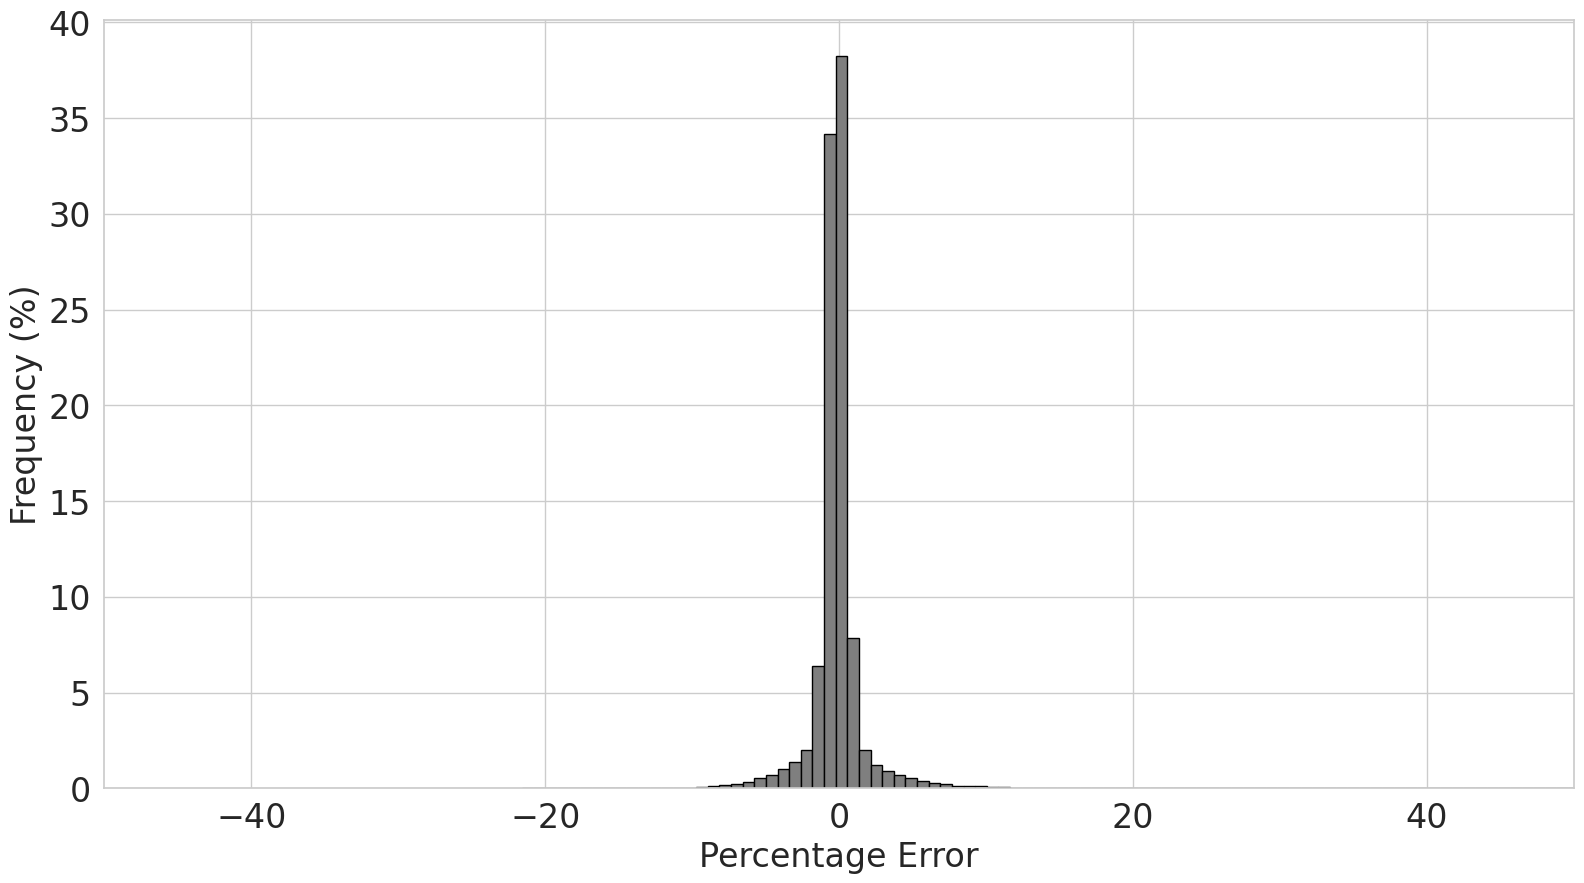

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 9))
plt.hist(
    expression_df["percentage_error"], 
    bins=100, 
    weights=[100 / len(expression_df)] * len(expression_df), 
    edgecolor='black', 
    color='tab:grey'
)

fontsize = 24
plt.xlim(-50, 50)  
plt.xlabel("Percentage Error", fontsize=fontsize)
plt.ylabel("Frequency (%)", fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.tight_layout()

save_as = "../../results/plots/measured_vs_predicted/bar/esm_gcn_BE.lr1e-04.expression-percent_error_histogram.pdf"
plt.savefig(save_as, format='pdf')
plt.savefig(save_as.replace('.pdf', '.png'), format='png')

In [11]:
lower_bound = expression_df['percentage_error'].quantile(0.025)
upper_bound = expression_df['percentage_error'].quantile(0.975)
outliers = expression_df[(expression_df['percentage_error'] < lower_bound) | (expression_df['percentage_error'] > upper_bound)].reset_index(drop=True)

df = outliers.copy()
df['target'] = df['seq_id'].str.rsplit('-', n=1).str[0]
df['aa_substitutions'] = df['seq_id'].str.rsplit('-', n=1).str[1].str.rsplit('_')
print(len(df))

df = df.explode('aa_substitutions')
print(len(df))

df['RBD_mutation_site'] = df['aa_substitutions'].str.extract(r'(\d+)').astype(int) + 330 # Extract numeric site, RBD site
df['original_aa'] = df['aa_substitutions'].str[0]
df['new_aa'] = df['aa_substitutions'].str[-1]
df['aa_sub'] = df['original_aa'] + ">" + df['new_aa']
df.head(5)

5138
17366


,seq_id,expression_predicted_value,RBD_expression,mode,percentage_error,target,aa_substitutions,RBD_mutation_site,original_aa,new_aa,aa_sub
0,SARS-CoV-2-V20S_T55E_T201P,7.606740,7.92,train,-3.955309,SARS-CoV-2,V20S,350,V,S,V>S
0,SARS-CoV-2-V20S_T55E_T201P,7.606740,7.92,train,-3.955309,SARS-CoV-2,T55E,385,T,E,T>E
0,SARS-CoV-2-V20S_T55E_T201P,7.606740,7.92,train,-3.955309,SARS-CoV-2,T201P,531,T,P,T>P
1,SARS-CoV-2-N4V_G152S,8.722918,8.31,train,4.968924,SARS-CoV-2,N4V,334,N,V,N>V
1,SARS-CoV-2-N4V_G152S,8.722918,8.31,train,4.968924,SARS-CoV-2,G152S,482,G,S,G>S


In [12]:
from collections import Counter

original_aa_dict = df.groupby('RBD_mutation_site')['original_aa'].apply(lambda x: list(set(x))).to_dict()
new_aa_dict = df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(set(x))).to_dict()

new_aa_total_ct_dict = df.groupby('RBD_mutation_site')['new_aa'].count().to_dict()
print(f"Per site total mutations: {new_aa_total_ct_dict}")

new_aa_ct_dict = df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(Counter(x).items())).to_dict()
sorted_new_aa_ct_dict = {k: sorted(v, key=lambda x: x[1], reverse=True) for k, v in new_aa_ct_dict.items()}
print(f"Per site, per new amino acid substitution total: {sorted_new_aa_ct_dict}")

Per site total mutations: {331: 88, 332: 132, 333: 115, 334: 112, 335: 185, 336: 160, 337: 75, 338: 81, 339: 137, 340: 100, 341: 76, 342: 98, 343: 77, 344: 156, 345: 131, 346: 49, 347: 52, 348: 49, 349: 85, 350: 55, 351: 44, 352: 57, 353: 73, 354: 42, 355: 62, 356: 55, 357: 75, 358: 57, 359: 38, 360: 37, 361: 47, 362: 51, 363: 121, 364: 130, 365: 137, 366: 112, 367: 145, 368: 84, 369: 70, 370: 80, 371: 177, 372: 146, 373: 85, 374: 140, 375: 121, 376: 54, 377: 63, 378: 71, 379: 90, 380: 65, 381: 96, 382: 48, 383: 60, 384: 78, 385: 145, 386: 136, 387: 59, 388: 83, 389: 86, 390: 140, 391: 218, 392: 106, 393: 105, 394: 133, 395: 48, 396: 46, 397: 37, 398: 87, 399: 46, 400: 47, 401: 44, 402: 28, 403: 53, 404: 41, 405: 30, 406: 39, 407: 97, 408: 36, 409: 13, 410: 30, 411: 86, 412: 78, 413: 143, 414: 103, 415: 93, 416: 185, 417: 157, 418: 82, 419: 118, 420: 232, 421: 131, 422: 66, 423: 73, 424: 125, 425: 105, 426: 117, 427: 144, 428: 137, 429: 156, 430: 131, 431: 56, 432: 46, 433: 132, 434: 9

In [13]:
data = []
for site in sorted(new_aa_total_ct_dict.keys()):
    total = new_aa_total_ct_dict[site]
    mutations = sorted_new_aa_ct_dict[site]
    mutation_str = ', '.join([f"{aa}({count})" for aa, count in mutations])
    data.append({
        'RBD Site': site,
        'Original Amino Acid': original_aa_dict[site][0],
        'Total Possible Mutations': total,
        'Amino Acid Substitutions (Count)': mutation_str
    })

possible_mutations_per_site = pd.DataFrame(data)
#print(possible_mutations_per_site.to_string(index=False))

# Sort and display the top 10
possible_mutations_per_site['Total Possible Mutations'] = pd.to_numeric(possible_mutations_per_site['Total Possible Mutations'])
top_10_highest = possible_mutations_per_site.sort_values('Total Possible Mutations', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site Original Amino Acid  Total Possible Mutations                                                                                             Amino Acid Substitutions (Count)
      531                   T                       265 R(34), L(30), K(24), S(24), V(23), Y(15), P(14), A(13), M(12), I(11), N(11), G(10), W(9), D(8), C(8), Q(7), F(6), E(4), H(2)
      420                   D                       232  S(31), Y(23), L(20), H(17), R(16), I(16), C(15), N(12), K(12), V(10), M(10), G(9), E(8), T(7), F(7), W(6), A(6), P(5), Q(2)
      391                   C                       218 L(24), R(17), V(16), S(16), G(15), K(14), P(12), Y(12), D(11), T(11), I(10), N(10), F(9), A(9), M(8), Q(7), H(6), E(6), W(5)
      479                   P                       203     L(32), T(26), S(22), N(17), H(14), R(12), Q(11), F(10), E(8), K(8), Y(7), A(7), C(5), G(5), D(5), V(4), W(4), M(3), I(3)
      449                   Y                       203    L(23), V(17), T(15), S(15), R(14), F

In [14]:
# Group by 'RBD_mutation_site' and extract all expression_predicted_value scores for each site
all_scores_dict = df.groupby('RBD_mutation_site').apply(
    lambda x: x[['new_aa', 'RBD_expression', 'expression_predicted_value', 'percentage_error']].values.tolist()
).to_dict()

# Find the highest expression_predicted_value score for each site
highest_scores = {site: max(scores, key=lambda x: x[2])[2] if scores else 0 for site, scores in all_scores_dict.items()}

data = []
for site, max_score in highest_scores.items():
    total = new_aa_total_ct_dict[site]
    scores = all_scores_dict.get(site, [])
    aa_str = ', '.join([f'{aa}' for aa, m_score, p_score, perc_error in scores])
    scores_str = ', '.join([f'{perc_error:.2f}' for aa, m_score, p_score, perc_error in scores])
    data.append({
        'RBD Site': site,
        'Total Mutations': total,
        'Original Amino Acid': original_aa_dict[site][0],
        'Highest Predicted Expression Value': f'{max_score:.2f}',
        'Amino Acid Substitutions': aa_str,
        'Perc Error': scores_str
    })

e_all_scores_per_site = pd.DataFrame(data)
#print(all_scores_per_site.to_string(index=False))

# Sort and display the top 10
e_all_scores_per_site['Highest Predicted Expression Value'] = pd.to_numeric(e_all_scores_per_site['Highest Predicted Expression Value'])
e_top_10_highest = e_all_scores_per_site.sort_values('Highest Predicted Expression Value', ascending=False).head(10)
print(e_top_10_highest.to_string(index=False))

sorted([[s, aa] for s, aa in zip(e_top_10_highest['RBD Site'].to_list(), e_top_10_highest['Original Amino Acid'].to_list())])

 RBD Site  Total Mutations Original Amino Acid  Highest Predicted Expression Value                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  Amino Acid Substitutions                                                                                                                            

[[346, 'R'],
 [354, 'N'],
 [358, 'I'],
 [362, 'V'],
 [365, 'Y'],
 [367, 'V'],
 [383, 'S'],
 [388, 'N'],
 [417, 'K'],
 [531, 'T']]

---
Use the original aa at that position. The error bar here is the percent of mutations that leads to increased (+) or decreased (-) binding (or mutation in a separate figure) with any of the mutations this position was invoved.
- First column is position, second one is AA, third column is impact.
- impact > 0 means "increase." that is a ratio. so 0.5 means 50% increase
- 1.0 means doubled.
- impact <0 means "decrease". -0.5 means half.

In [16]:
import pandas as pd
import numpy as np

def calculate_impact(data):
    data = data.copy()

    # Convert percent error strings to floats
    data['Perc Error'] = data['Perc Error'].str.split(', ').apply(lambda x: [float(i) for i in x])
    
    # Calculate impact
    def impact(errors):
        total = len(errors)
        increased = sum(1 for e in errors if e > 0)
        decreased = sum(1 for e in errors if e < 0)
        return {
            'increased': (increased / total) * 100,
            'decreased': (decreased / total) * 100,
            'neutral': ((total - increased - decreased) / total) * 100,
            'impact': (increased - decreased) / total
        }
    
    results = data.apply(lambda row: impact(row['Perc Error']), axis=1)
    
    impact_df = pd.DataFrame(results.tolist(), index=data.index)
    
    # Add RBD Site and Original Amino Acid columns
    impact_df['RBD Site'] = data['RBD Site']
    impact_df['Original Amino Acid'] = data['Original Amino Acid']
    columns_order = ['RBD Site', 'Original Amino Acid', 'increased', 'decreased', 'neutral', 'impact']
    impact_df = impact_df[columns_order]

    impact_df = impact_df.sort_values('RBD Site')
    
    return impact_df

b_impact_results = calculate_impact(b_all_scores_per_site)
print(b_impact_results.head(5))

e_impact_results = calculate_impact(e_all_scores_per_site)
print(e_impact_results.head(5))

   RBD Site Original Amino Acid  increased  decreased  neutral    impact
0       331                   N  57.291667  42.708333      0.0  0.145833
1       332                   I  41.406250  58.593750      0.0 -0.171875
2       333                   T  48.031496  51.968504      0.0 -0.039370
3       334                   N  55.208333  44.791667      0.0  0.104167
4       335                   L  54.335260  45.664740      0.0  0.086705
   RBD Site Original Amino Acid  increased  decreased  neutral    impact
0       331                   N  54.545455  45.454545      0.0  0.090909
1       332                   I  56.818182  43.181818      0.0  0.136364
2       333                   T  54.782609  45.217391      0.0  0.095652
3       334                   N  54.464286  45.535714      0.0  0.089286
4       335                   L  49.729730  50.270270      0.0 -0.005405


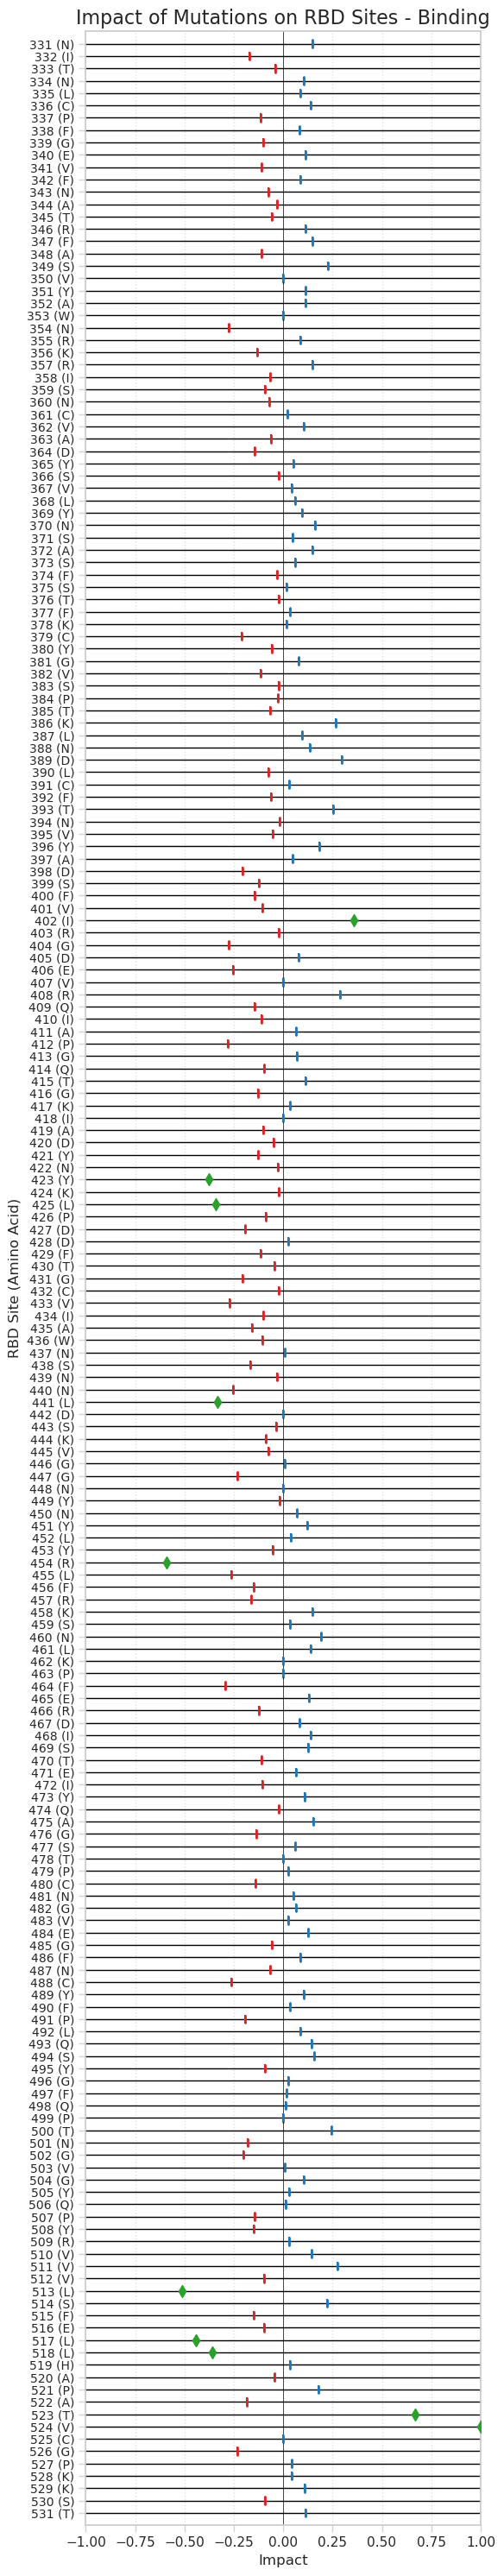

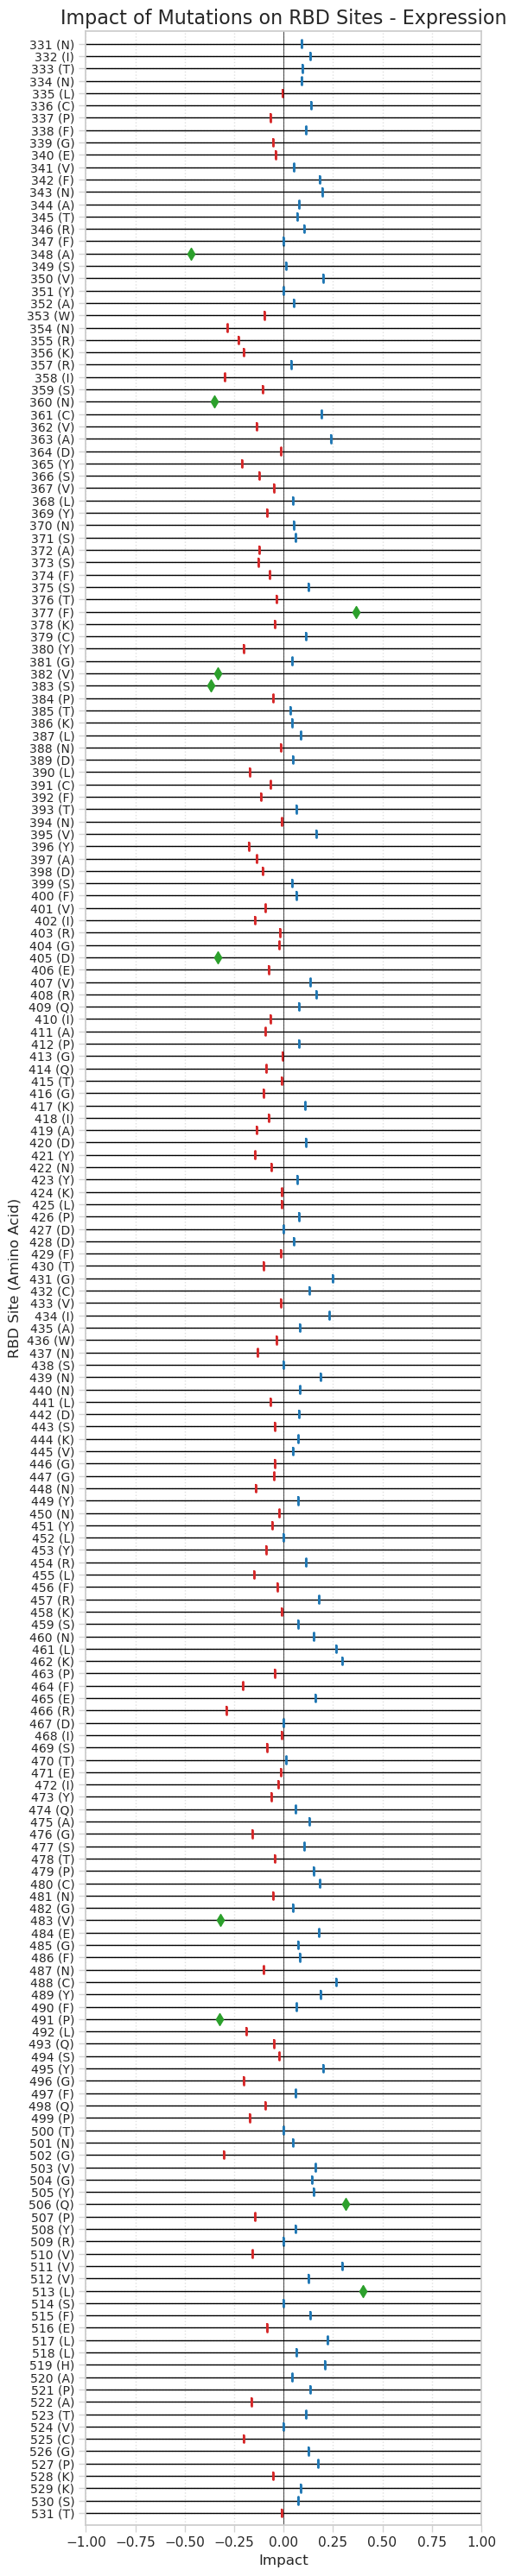

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_mutational_impact_a(impact_results_df, BorE):
    # Sort the DataFrame by RBD Site
    df = impact_results_df.sort_values('RBD Site', ascending=False).copy()

    # Find the top 10 impacts by absolute value
    top_10_indices = df['impact'].abs().nlargest(10).index
    print(top_10_indices)

    # Create the plot
    plt.figure(figsize=(6, 30))

    # Plot individual lines for each RBD site
    for _, row in df.iterrows():
        # Horizontal black line from -1 to 1
        plt.plot([-1, 1], [row['RBD Site'], row['RBD Site']], color='black', linewidth=1, zorder=1)
        
        # Vertical colored line at the impact value
        if row.name in top_10_indices:
            line_color = 'tab:green'
            marker = 'd'  # Shape for top 10
            size = 50
        else:
            line_color = 'tab:red' if row['impact'] < 0 else 'tab:blue'
            marker = '|'  # Vertical line for others
            size = 50
        
        plt.plot([row['impact'], row['impact']], [row['RBD Site']-0.3, row['RBD Site']+0.3], 
                color=line_color, linewidth=2, zorder=2)
        plt.scatter(row['impact'], row['RBD Site'], color=line_color, marker=marker, s=size, zorder=3)

    # Customize the plot
    plt.title(f'Impact of Mutations on RBD Sites - {BorE}', fontsize=16)
    plt.xlabel('Impact', fontsize=12)
    plt.ylabel('RBD Site (Amino Acid)', fontsize=12)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

    # Set axis range
    plt.ylim(532, 330)
    plt.xlim(-1, 1)

    # Add primary y-axis labels (Amino Acids)
    plt.yticks(df['RBD Site'], [f"{site} ({aa})" for site, aa in zip(df['RBD Site'], df['Original Amino Acid'])])
    plt.tick_params(axis='y', which='major', labelsize=10)

    # Ensure tick marks appear outside the axes
    plt.tick_params(
        axis='both',       
        direction='out',   
        width=1,          
        left=True,      
        right=False,        
        bottom=True,        
        top=False,      
        color="lightgrey"
    )

    plt.grid(True, linestyle=':', color='lightgrey', alpha=0.7)

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

plot_mutational_impact_a(b_impact_results, "Binding")
plot_mutational_impact_a(e_impact_results, "Expression")

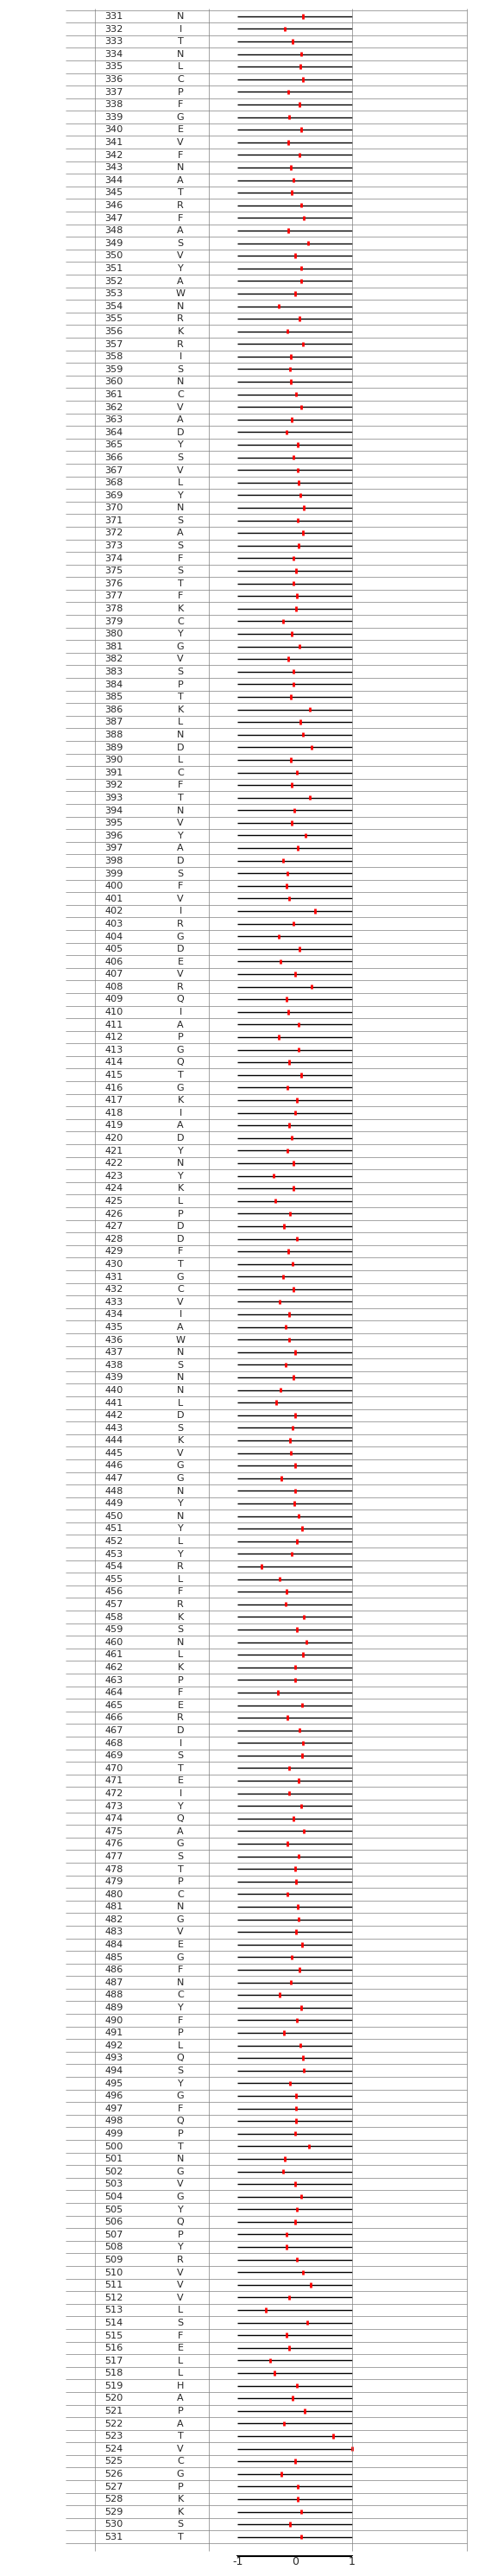

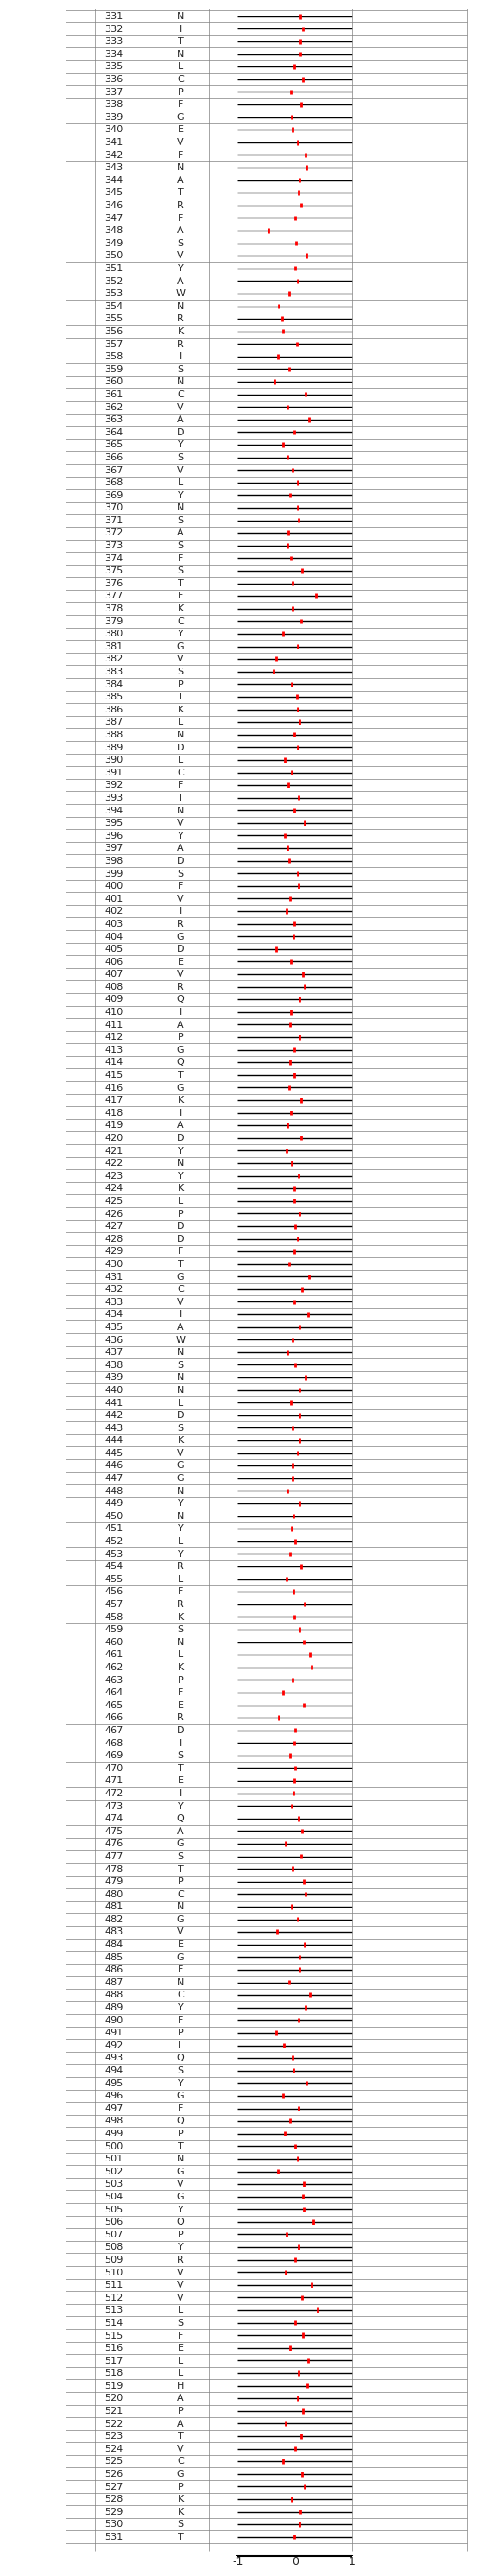

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_mutational_impact_b(impact_results_df, BorE):
    # ---------------------------------------------------
    # 1. Data
    # ---------------------------------------------------
    df = impact_results_df.copy()

    # ---------------------------------------------------
    # 2. Figure and Axes Setup
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 30))

    # Hide the main axes (we will manually place text and lines)
    ax.set_axis_off()

    # Some layout parameters
    x_text_col1 = -0.1   # X-position for the Position column text
    x_text_col2 =  0.1   # X-position for the AA column text
    x_bar_start =  0.3   # X-position where the bar starts (maps to -1)
    bar_width    =  0.4  # Width of the bar region (maps to -1..1)

    row_height = 0.8
    # We'll invert the y-axis so that row 0 is at the top
    y_top = row_height * (len(df) - 0.5)

    # Make sure our axis limits encompass all we draw
    ax.set_xlim(-0.5, 1.2)
    # Leave some space at the bottom (for the custom tick labels)
    ax.set_ylim(-1, y_top + 0.5)

    # ---------------------------------------------------
    # 3. Draw each row of the "table"
    # ---------------------------------------------------
    for i, (idx, row) in enumerate(df.iterrows()):
        # i goes from 0 to (len(df)-1)
        # We'll place the top row at the top and move downward.
        y_row = y_top - i*row_height

        # A) Position text (column 1)
        ax.text(x_text_col1, y_row, f"{row['RBD Site']}",
                va='center', ha='right', fontsize=8)

        # B) Amino acid text (column 2)
        ax.text(x_text_col2, y_row, f"{row['Original Amino Acid']}",
                va='center', ha='center', fontsize=8)

        # C) Horizontal bar for impact (column 3)
        #    The bar extends from -1 to 1, but we visually map that to
        #    x_bar_start -> x_bar_start+bar_width in this Axes.
        bar_left = x_bar_start
        bar_right = x_bar_start + bar_width
        ax.hlines(y_row, bar_left, bar_right, color='black', linewidth=1)

        # Vertical line for the impact value
        impact_val = row['impact']  # in [-1, 1]
        # Convert impact_val to [0..1] fraction across bar_width
        frac = (impact_val - (-1)) / 2.0  # 0.0 when -1, 1.0 when +1
        x_impact = bar_left + frac * bar_width

        ax.vlines(x_impact, y_row - 0.15, y_row + 0.15, color='red', linewidth=2)

    # ---------------------------------------------------
    # 4. (Optional) Draw table boundary lines
    # ---------------------------------------------------
    # Horizontal separators
    for i in range(len(df)+1):
        y_line = y_top - (i-0.5)*row_height
        ax.hlines(y_line, -0.3, 1.1, color='gray', linewidth=0.5)

    # Vertical separators (adjust x-positions to match how you placed text/bars)
    for x_sep in [-0.2, 0.2, 0.7, 1.1]:
        ax.vlines(x_sep, -0.5, y_top + 0.5, color='gray', linewidth=0.5)

    # ---------------------------------------------------
    # 5. Add x-axis ticks at [-1, 0, 1] for the bar region
    # ---------------------------------------------------
    # We know x_bar_start (0.3) corresponds to -1, and (x_bar_start + bar_width) (0.7) corresponds to +1.
    # So the halfway point (0.5) is 0.
    tick_line_y = -0.8  # a bit below the bottom row
    ax.hlines(tick_line_y, x_bar_start, x_bar_start + bar_width, color='black')  # horizontal axis line

    tick_positions = [x_bar_start, x_bar_start + 0.5*bar_width, x_bar_start + bar_width]
    tick_labels    = ['-1', '0', '1']

    # Draw short vertical lines and label them
    for xpos, tlabel in zip(tick_positions, tick_labels):
        ax.vlines(xpos, tick_line_y, tick_line_y + 0.03, color='black')
        ax.text(xpos, tick_line_y - 0.02, tlabel, ha='center', va='top', fontsize=9)

    # ---------------------------------------------------
    # 6. Show or Save the Figure
    # ---------------------------------------------------
    plt.tight_layout()
    plt.show()

plot_mutational_impact_b(b_impact_results, "Binding")
plot_mutational_impact_b(e_impact_results, "Expression")